# 🐸 Boiling Frog Effect: Multi-Model Semantic Drift Pipeline

## Cross-Domain, Cross-Model Analysis of Iterative LLM Paraphrasing
### Khoury College of Computer Science, Northeastern University

**Research Question:** Does the Boiling Frog Effect persist across different paraphrase models and text domains? With a 3-hop chain (Type1 → 5_1st → 5_2nd → 5_3rd), does adding the intermediate 2nd iteration reveal drift dynamics hidden in 2-hop analysis?

**Pipeline Architecture:**
```
[Extract 49 files] → [Validate] → [Profile] → [Clean] → [Embed] → [Compute] → [Verify] → [Analyze] → [Export]
  7 domains ×          Pydantic    Quality     Filter   SBERT      3 hops     Sanity     Boiling     Results
  7 models             Schema      Report      Artifacts (cached)  + E2E      Checks     Frog        & Logs
```

**Dataset:** 21,140 records across 7 domains × 7 paraphrase models  
**Domains:** CMV, ELI5, SCI, TLDR, WP, XSUM, YELP  
**Models:** ChatGPT, DIPPER, DIPPER(low), DIPPER(high), PaLM, Pegasus(full), Pegasus(slight)  
**Chain:** Type 1 (Human) → Type 5-1st → Type 5-2nd → Type 5-3rd (3 hops)

---
## Section 0: Configuration & Environment Setup

In [1]:
# 0A: INSTALL (run once)
%pip install sentence-transformers nltk rouge-score bert-score scipy scikit-learn seaborn tqdm python-Levenshtein pydantic ftfy watermark --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# 0B: IMPORTS
import json
import re
import os
import sys
import time
import hashlib
import logging
import warnings
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Any, Optional, Tuple
from collections import defaultdict

import pandas as pd
import numpy as np
from pydantic import BaseModel, Field, field_validator, model_validator
from sentence_transformers import SentenceTransformer
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from scipy.spatial.distance import euclidean, cosine
from scipy.stats import spearmanr, pearsonr
from sklearn.preprocessing import MinMaxScaler
import Levenshtein as lev_module

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import nltk
import torch
import gc

try:
    import ftfy
    FTFY_AVAILABLE = True
except ImportError:
    FTFY_AVAILABLE = False
    print("⚠️ ftfy not installed — encoding checks skipped")

warnings.filterwarnings('ignore')
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print("✅ All imports successful")

✅ All imports successful


In [3]:
# 0C: PIPELINE CONFIGURATION
@dataclass
class PipelineConfig:
    """Central configuration for multi-model semantic drift pipeline."""
    # --- Paths ---
    data_dir: str = './output_json'        # Directory with domain/model JSON files
    output_dir: str = './outputs'
    cache_dir: str = './cache'
    log_dir: str = './logs'

    # --- Column names ---
    col_type1: str = 'human_original_text(type1)'
    col_type5_1st: str = 'llm_paraphrased_generated_text(type5)-1st'
    col_type5_2nd: str = 'llm_paraphrased_generated_text(type5)-2nd'
    col_type5_3rd: str = 'llm_paraphrased_generated_text(type5)-3rd'

    # --- Model ---
    sbert_model: str = 'all-mpnet-base-v2'
    sbert_batch_size: int = 64

    # --- Composite SDS Weights ---
    weight_sbert: float = 0.6
    weight_meteor: float = 0.2
    weight_rouge: float = 0.2

    # --- Thresholds ---
    parascore_threshold: float = 0.35
    low_med_threshold: float = 0.35
    med_high_threshold: float = 0.45

    # --- Quality gates ---
    min_completeness_pct: float = 95.0
    min_token_length: int = 3
    max_token_length: int = 2000

    # --- Artifact detection ---
    artifact_rouge_threshold: float = 0.05
    artifact_sbert_threshold: float = 0.10

    # --- Reproducibility ---
    seed: int = 42
    device: str = 'auto'

    def __post_init__(self):
        for d in [self.output_dir, self.cache_dir, self.log_dir]:
            Path(d).mkdir(parents=True, exist_ok=True)

CFG = PipelineConfig()
print("✅ Pipeline configuration initialized")
print(f"   Data dir:    {CFG.data_dir}")
print(f"   SBERT model: {CFG.sbert_model}")
print(f"   SDS weights: SBERT={CFG.weight_sbert}, METEOR={CFG.weight_meteor}, ROUGE={CFG.weight_rouge}")
print(f"   ParaScore γ: {CFG.parascore_threshold}")

✅ Pipeline configuration initialized
   Data dir:    ./output_json
   SBERT model: all-mpnet-base-v2
   SDS weights: SBERT=0.6, METEOR=0.2, ROUGE=0.2
   ParaScore γ: 0.35


In [4]:
# 0D: SEED SETTING & DEVICE
import random

def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_all_seeds(CFG.seed)
DEVICE = 'cuda' if (CFG.device == 'auto' and torch.cuda.is_available()) else 'cpu' if CFG.device == 'auto' else CFG.device
print(f"✅ Seeds set to {CFG.seed}")
print(f"✅ Device: {DEVICE}", end="")
if DEVICE == 'cuda':
    print(f" — {torch.cuda.get_device_name(0)}")
else:
    print()

✅ Seeds set to 42
✅ Device: cuda — NVIDIA GeForce RTX 4060 Laptop GPU


In [5]:
# 0E: LOGGING
def setup_logger(name, log_dir):
    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)
    logger.handlers = []
    fmt = logging.Formatter('%(asctime)s | %(levelname)-7s | %(message)s', datefmt='%H:%M:%S')
    ch = logging.StreamHandler(); ch.setFormatter(fmt); logger.addHandler(ch)
    fh = logging.FileHandler(Path(log_dir) / f'pipeline_{time.strftime("%Y%m%d_%H%M%S")}.log')
    fh.setFormatter(fmt); logger.addHandler(fh)
    return logger

log = setup_logger('boiling_frog_v2', CFG.log_dir)
log.info("Pipeline logger initialized")
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams.update({'figure.figsize': (14, 10), 'font.size': 11, 'figure.dpi': 100})

20:12:48 | INFO    | Pipeline logger initialized


---
## Section 1: Data Ingestion & Schema Validation

Loading 49 JSON files (7 domains × 7 paraphrase models), adding `domain` and `paraphrase_model` metadata columns, and validating each record with Pydantic.

In [6]:
# 1A: PYDANTIC SCHEMA — adapted for this dataset (Type2/3/4 are null)
class MultiModelRecord(BaseModel):
    """Schema for multi-model paraphrase records.
    Only Type1 and Type5 iterations are populated; Type2/3/4 are null."""
    idx: int = Field(ge=0)
    dataset_source: str
    type1: str = Field(alias='human_original_text(type1)', min_length=1)
    type5_1st: str = Field(alias='llm_paraphrased_generated_text(type5)-1st', min_length=1)
    type5_2nd: str = Field(alias='llm_paraphrased_generated_text(type5)-2nd', min_length=1)
    type5_3rd: str = Field(alias='llm_paraphrased_generated_text(type5)-3rd', min_length=1)

    model_config = {"populate_by_name": True, "extra": "allow"}

    @field_validator('type1', 'type5_1st', 'type5_2nd', 'type5_3rd')
    @classmethod
    def validate_not_whitespace(cls, v, info):
        if not str(v).strip():
            raise ValueError(f"Field '{info.field_name}' is whitespace-only")
        return str(v).strip()

print("✅ Pydantic schema defined: MultiModelRecord")

✅ Pydantic schema defined: MultiModelRecord


In [7]:
# 1B: EXTRACT — Load all 49 files with domain/model metadata
pipeline_start = time.time()
log.info(f"Loading data from {CFG.data_dir}")

all_records = []
file_inventory = []

data_dir = Path(CFG.data_dir)
for domain_dir in sorted(data_dir.iterdir()):
    if not domain_dir.is_dir() or domain_dir.name.startswith('_'):
        continue
    domain = domain_dir.name
    for json_file in sorted(domain_dir.glob('*.json')):
        model_name = json_file.stem  # e.g., 'chatgpt', 'dipper(low)'

        with open(json_file, 'r', encoding='utf-8') as f:
            records = json.load(f)

        for record in records:
            record['_domain'] = domain
            record['_paraphrase_model'] = model_name

        all_records.extend(records)
        file_inventory.append({'domain': domain, 'model': model_name, 'records': len(records)})

log.info(f"Loaded {len(all_records):,} raw records from {len(file_inventory)} files")

inv_df = pd.DataFrame(file_inventory)
print(f"\n{'='*60}")
print(f"📂 DATA EXTRACTION SUMMARY")
print(f"{'='*60}")
print(f"   Files loaded:     {len(file_inventory)}")
print(f"   Total records:    {len(all_records):,}")
print(f"   Domains:          {sorted(inv_df['domain'].unique())}")
print(f"   Models:           {sorted(inv_df['model'].unique())}")
print(f"\n📊 Records per Domain × Model:")
pivot = inv_df.pivot_table(index='domain', columns='model', values='records', aggfunc='sum')
print(pivot.to_string())

20:12:48 | INFO    | Loading data from ./output_json
20:12:49 | INFO    | Loaded 21,140 raw records from 49 files



📂 DATA EXTRACTION SUMMARY
   Files loaded:     49
   Total records:    21,140
   Domains:          ['CMV', 'ELI5', 'SCI', 'TLDR', 'WP', 'XSUM', 'YELP']
   Models:           ['chatgpt', 'dipper', 'dipper(high)', 'dipper(low)', 'palm', 'pegasus(full)', 'pegasus(slight)']

📊 Records per Domain × Model:
model   chatgpt  dipper  dipper(high)  dipper(low)  palm  pegasus(full)  pegasus(slight)
domain                                                                                  
CMV         256     256           256          256   256            256              256
ELI5        475     475           475          475   475            475              475
SCI         471     471           471          471   471            471              471
TLDR        382     382           382          382   382            382              382
WP          469     469           469          469   469            469              469
XSUM        476     476           476          476   476            476    

In [8]:
# 1C: VALIDATE
valid_records = []
invalid_records = []

for i, record in enumerate(tqdm(all_records, desc="Validating records")):
    try:
        # Only validate non-null required fields
        validated = MultiModelRecord(**record)
        valid_records.append(record)
    except Exception as e:
        invalid_records.append({'index': i, 'idx': record.get('idx', '?'),
                                'domain': record.get('_domain', '?'),
                                'model': record.get('_paraphrase_model', '?'),
                                'error': str(e)[:200]})

log.info(f"Validation: {len(valid_records):,} valid, {len(invalid_records):,} invalid")

if invalid_records:
    inv_fail_df = pd.DataFrame(invalid_records)
    inv_fail_df.to_csv(Path(CFG.output_dir) / 'validation_failures.csv', index=False)
    log.warning(f"⚠️ {len(invalid_records)} records failed — see validation_failures.csv")
    print(f"\n⚠️ Failures by model:")
    print(inv_fail_df.groupby('model').size().to_string())
else:
    log.info("✅ All records passed schema validation")

failure_pct = len(invalid_records) / len(all_records) * 100
if failure_pct > 5.0:
    raise RuntimeError(f"🛑 HALTED: {failure_pct:.1f}% failed validation")

# Build DataFrame
df = pd.DataFrame(valid_records)
df['Type_1'] = df[CFG.col_type1].astype(str)
df['Type_5_1st'] = df[CFG.col_type5_1st].astype(str)
df['Type_5_2nd'] = df[CFG.col_type5_2nd].astype(str)
df['Type_5_3rd'] = df[CFG.col_type5_3rd].astype(str)
df['domain'] = df['_domain']
df['model'] = df['_paraphrase_model']

data_hash = hashlib.md5(json.dumps(len(valid_records)).encode()).hexdigest()[:12]
log.info(f"Data fingerprint: {data_hash}")

print(f"\n✅ {len(df):,} valid records loaded")
print(f"   Failure rate: {failure_pct:.2f}%")

Validating records:   0%|          | 0/21140 [00:00<?, ?it/s]

20:12:49 | INFO    | Validation: 21,122 valid, 18 invalid
20:12:49 | WARNING | ⚠️ 18 records failed — see validation_failures.csv



⚠️ Failures by model:
model
dipper(high)     2
palm            16


20:12:49 | INFO    | Data fingerprint: eae6b5d089d0



✅ 21,122 valid records loaded
   Failure rate: 0.09%


---
## Section 2: Data Profiling & Quality Report

In [9]:
# 2A: COMPLETENESS & STATS
log.info("Running data quality profiling...")

def tokenize(text):
    return re.findall(r'\w+', str(text).lower())

type_cols = {
    'Type_1': 'Human Original',
    'Type_5_1st': 'Iter-1',
    'Type_5_2nd': 'Iter-2',
    'Type_5_3rd': 'Iter-3'
}

quality_rows = []
for col, label in type_cols.items():
    texts = df[col]
    token_lengths = texts.apply(lambda x: len(tokenize(x)))
    non_empty = texts.apply(lambda x: bool(str(x).strip()) and str(x) != 'None').sum()
    completeness = non_empty / len(df) * 100
    n_dupes = texts.duplicated().sum()
    n_short = (token_lengths < CFG.min_token_length).sum()
    n_encoding = 0
    if FTFY_AVAILABLE:
        for t in texts.sample(min(1000, len(texts)), random_state=CFG.seed):
            if ftfy.fix_text(str(t)) != str(t):
                n_encoding += 1

    quality_rows.append({
        'Text Type': label, 'Column': col,
        'Completeness (%)': round(completeness, 2),
        'Duplicates': n_dupes,
        'Mean Tokens': round(token_lengths.mean(), 1),
        'Median Tokens': round(token_lengths.median(), 1),
        'Min Tokens': token_lengths.min(),
        'Max Tokens': token_lengths.max(),
        'Short (<3)': n_short,
        'Encoding Issues (sample)': n_encoding
    })

quality_df = pd.DataFrame(quality_rows)
print(f"{'='*60}")
print(f"📋 DATA QUALITY REPORT ({len(df):,} records)")
print(f"{'='*60}")
print(quality_df[['Text Type', 'Completeness (%)', 'Duplicates', 'Mean Tokens',
                   'Median Tokens', 'Short (<3)']].to_string(index=False))

for _, row in quality_df.iterrows():
    if row['Completeness (%)'] < CFG.min_completeness_pct:
        raise RuntimeError(f"🛑 QUALITY GATE: {row['Text Type']} completeness = {row['Completeness (%)']}%")

log.info("✅ All quality gates passed")
quality_df.to_csv(Path(CFG.output_dir) / 'data_quality_report.csv', index=False)

20:12:49 | INFO    | Running data quality profiling...
20:12:53 | INFO    | ✅ All quality gates passed


📋 DATA QUALITY REPORT (21,122 records)
     Text Type  Completeness (%)  Duplicates  Mean Tokens  Median Tokens  Short (<3)
Human Original             100.0       18102        273.8          183.0           0
        Iter-1             100.0          32        226.5          137.0           2
        Iter-2             100.0          14        201.9          125.0           7
        Iter-3             100.0          24        186.1          117.0           9


In [10]:
# 2A.1: PAPER TABLE 1 — Token-Length Statistics (Source vs Final Paraphrase)
# Computes the same summary as the SemanticDrift pipeline's paper_table1_length_stats.csv
# for the Ship of Theseus corpus: Type_1 (Source) vs Type_5_3rd (Final Paraphrase).

def tokenize_for_stats(text):
    return re.findall(r'\w+', str(text).lower())

source_lengths = df['Type_1'].apply(lambda x: len(tokenize_for_stats(x)))
paraph_lengths = df['Type_5_3rd'].apply(lambda x: len(tokenize_for_stats(x)))

table1_data = {
    'Metric': ['Mean', 'Std. Dev.', 'Min', 'Median', 'Max'],
    'Source (T1)': [
        round(source_lengths.mean(), 2),
        round(source_lengths.std(), 2),
        source_lengths.min(),
        source_lengths.median(),
        source_lengths.max(),
    ],
    'Paraphrase (T5-3rd)': [
        round(paraph_lengths.mean(), 2),
        round(paraph_lengths.std(), 2),
        paraph_lengths.min(),
        paraph_lengths.median(),
        paraph_lengths.max(),
    ],
}
table1_data['Delta'] = [
    round(table1_data['Paraphrase (T5-3rd)'][i] - table1_data['Source (T1)'][i], 2)
    for i in range(5)
]

table1_df = pd.DataFrame(table1_data)
table1_df.to_csv(Path(CFG.output_dir) / 'paper_table1_length_stats.csv', index=False)

print("=" * 70)
print("PAPER TABLE 1 — Ship of Theseus Token-Length Statistics")
print("=" * 70)
print(f"Records: {len(df):,}")
print()
print(table1_df.to_string(index=False))
print()
log.info(f"Table 1 stats exported to {CFG.output_dir}/paper_table1_length_stats.csv")

20:12:55 | INFO    | Table 1 stats exported to ./outputs/paper_table1_length_stats.csv


PAPER TABLE 1 — Ship of Theseus Token-Length Statistics
Records: 21,122

   Metric  Source (T1)  Paraphrase (T5-3rd)  Delta
     Mean       273.79               186.06 -87.73
Std. Dev.       287.68               188.50 -99.18
      Min         6.00                 1.00  -5.00
   Median       183.00               117.00 -66.00
      Max      5764.00              6654.00 890.00



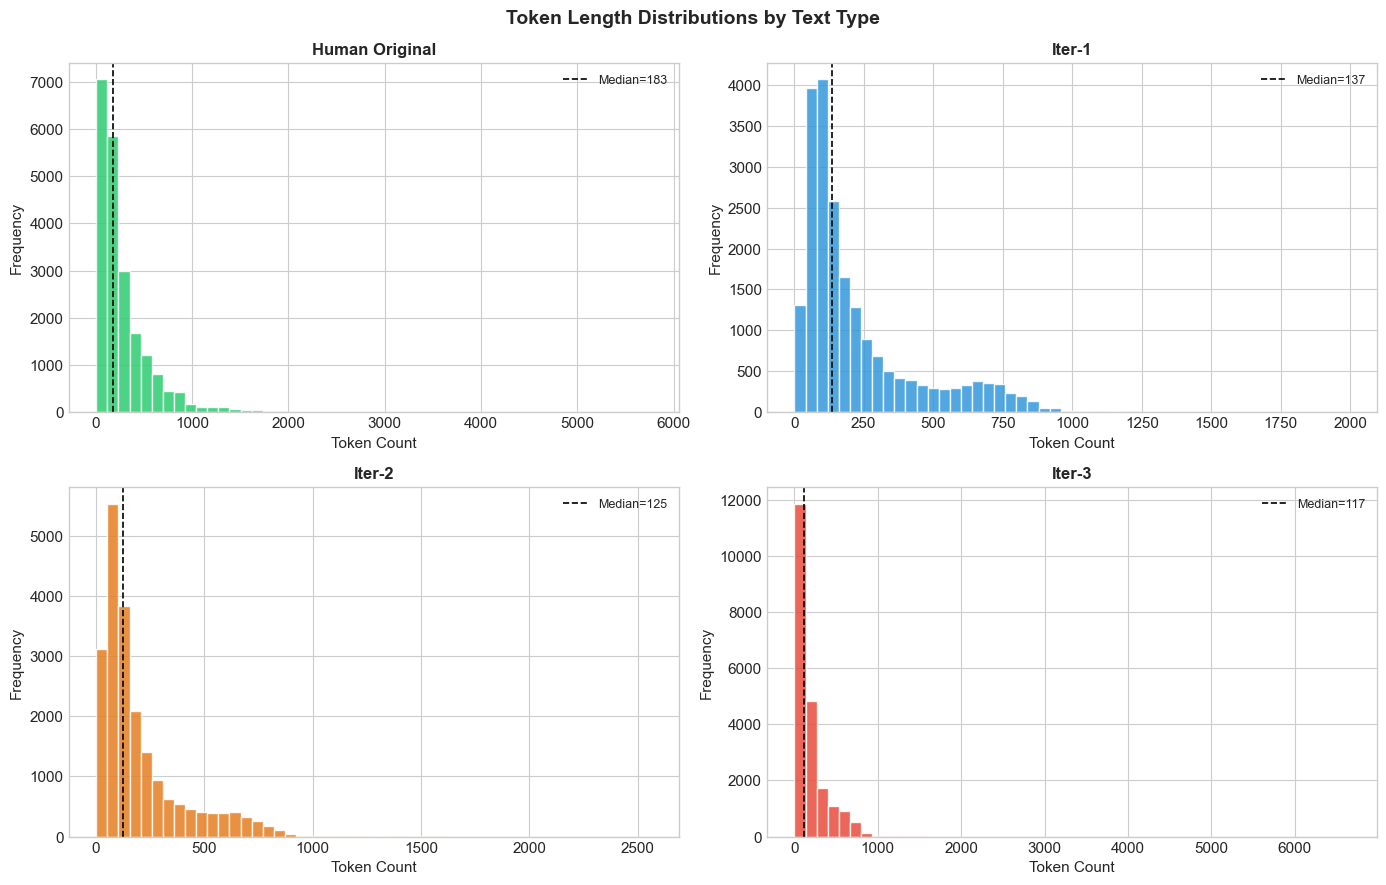

In [11]:
# 2B: TOKEN LENGTH DISTRIBUTIONS
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

for i, (col, label) in enumerate(type_cols.items()):
    tl = df[col].apply(lambda x: len(tokenize(x)))
    axes[i].hist(tl, bins=50, edgecolor='white', alpha=0.85, color=colors[i])
    axes[i].axvline(tl.median(), color='black', linestyle='--', linewidth=1.2, label=f'Median={tl.median():.0f}')
    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Token Count'); axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

fig.suptitle('Token Length Distributions by Text Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(Path(CFG.output_dir) / 'fig_token_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

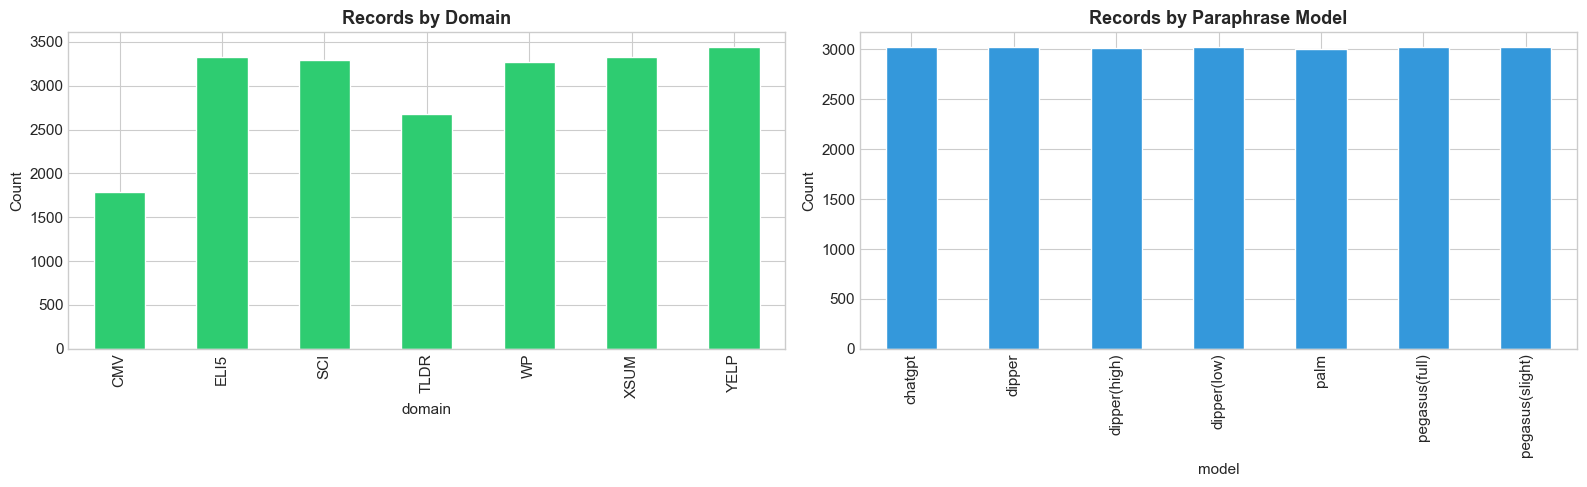

In [12]:
# 2C: DOMAIN × MODEL DISTRIBUTION
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['domain'].value_counts().sort_index().plot(kind='bar', color='#2ecc71', edgecolor='white', ax=axes[0])
axes[0].set_title('Records by Domain', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

df['model'].value_counts().sort_index().plot(kind='bar', color='#3498db', edgecolor='white', ax=axes[1])
axes[1].set_title('Records by Paraphrase Model', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(Path(CFG.output_dir) / 'fig_domain_model_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3: Preprocessing & Cleaning

In [13]:
# 3: PREPROCESSING
log.info("Preprocessing...")
n_before = len(df)

if FTFY_AVAILABLE:
    for col in type_cols.keys():
        df[col] = df[col].apply(lambda x: ftfy.fix_text(str(x)))

for col in type_cols.keys():
    df[col] = df[col].apply(lambda x: ' '.join(str(x).split()))

# Remove records with None/empty in any required field
mask = pd.Series(True, index=df.index)
for col in type_cols.keys():
    mask &= df[col].apply(lambda x: bool(str(x).strip()) and str(x).strip().lower() != 'none')

df = df[mask].reset_index(drop=True)
log.info(f"Preprocessing: {n_before} → {len(df)} records ({n_before - len(df)} removed)")
print(f"✅ Preprocessing complete: {len(df):,} records")

20:12:58 | INFO    | Preprocessing...
20:13:11 | INFO    | Preprocessing: 21122 → 21122 records (0 removed)


✅ Preprocessing complete: 21,122 records


---
## Section 4: SBERT Embedding Computation (with Caching)

With ~21K records × 4 text types = ~84K texts to embed. Cached as `.npy` files.

In [14]:
# 4: SBERT EMBEDDINGS
log.info(f"Loading SBERT model: {CFG.sbert_model}")
sbert_model = SentenceTransformer(CFG.sbert_model, device=DEVICE)
log.info(f"Model loaded (dim={sbert_model.get_sentence_embedding_dimension()})")

def compute_or_load_embeddings(texts: pd.Series, label: str) -> np.ndarray:
    cache_file = Path(CFG.cache_dir) / f'emb_{label}_{data_hash}_{len(texts)}.npy'
    if cache_file.exists():
        log.info(f"  Cache HIT: {label}")
        return np.load(cache_file)
    log.info(f"  Cache MISS: {label} — computing {len(texts):,} embeddings...")
    t0 = time.time()
    embs = sbert_model.encode(texts.tolist(), batch_size=CFG.sbert_batch_size,
                               show_progress_bar=True, normalize_embeddings=True, device=DEVICE)
    np.save(cache_file, embs)
    log.info(f"  Cached {label}: {embs.shape} in {time.time()-t0:.1f}s")
    return embs

print(f"{'='*60}")
print("🔄 COMPUTING / LOADING SBERT EMBEDDINGS")
print(f"{'='*60}")
emb_type1     = compute_or_load_embeddings(df['Type_1'], 'type1')
emb_type5_1st = compute_or_load_embeddings(df['Type_5_1st'], 'type5_1st')
emb_type5_2nd = compute_or_load_embeddings(df['Type_5_2nd'], 'type5_2nd')
emb_type5_3rd = compute_or_load_embeddings(df['Type_5_3rd'], 'type5_3rd')
print(f"\n✅ All embeddings ready — shape: {emb_type1.shape}")

20:13:11 | INFO    | Loading SBERT model: all-mpnet-base-v2
20:13:14 | INFO    | Model loaded (dim=768)
20:13:14 | INFO    |   Cache HIT: type1
20:13:14 | INFO    |   Cache HIT: type5_1st
20:13:14 | INFO    |   Cache HIT: type5_2nd
20:13:14 | INFO    |   Cache HIT: type5_3rd


🔄 COMPUTING / LOADING SBERT EMBEDDINGS

✅ All embeddings ready — shape: (21122, 768)


---
## Section 5: Multi-Metric Drift Computation

**3 hops + E2E** — cost-ascending order per hop:

| Hop | From | To | What it measures |
|-----|------|----|------------------|
| Hop A | Type 1 | Type 5-1st | First iteration drift from human original |
| Hop B | Type 5-1st | Type 5-2nd | Second iteration drift |
| Hop C | Type 5-2nd | Type 5-3rd | Third iteration drift |
| E2E | Type 1 | Type 5-3rd | Total cumulative drift |

In [15]:
# 5A: METRIC FUNCTIONS
def calc_jaccard(texts1, texts2):
    scores = []
    for t1, t2 in zip(texts1, texts2):
        s1, s2 = set(tokenize(t1)), set(tokenize(t2))
        scores.append(len(s1 & s2) / max(1, len(s1 | s2)) if (s1 or s2) else 1.0)
    return np.array(scores)

def calc_rouge_l(texts1, texts2):
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    return np.array([scorer.score(str(t1), str(t2))['rougeL'].fmeasure for t1, t2 in zip(texts1, texts2)])

def calc_meteor(texts1, texts2):
    scores = []
    for t1, t2 in tqdm(zip(texts1, texts2), total=len(texts1), desc="METEOR"):
        scores.append(meteor_score([tokenize(t1)], tokenize(t2)))
    return np.array(scores)

def calc_sbert_cosine(emb1, emb2):
    return np.array([1 - cosine(e1, e2) for e1, e2 in zip(emb1, emb2)])

def calc_sbert_euclidean(emb1, emb2):
    return np.array([euclidean(e1, e2) for e1, e2 in zip(emb1, emb2)])

def calc_edit_distance(texts1, texts2):
    scores = []
    for t1, t2 in zip(texts1, texts2):
        ml = max(len(str(t1)), len(str(t2)))
        scores.append(lev_module.distance(str(t1), str(t2)) / ml if ml > 0 else 0.0)
    return np.array(scores)

print("✅ Metric functions defined")

✅ Metric functions defined


In [16]:
# 5B: COMPUTE ALL METRICS PER HOP
def compute_hop_metrics(texts_ref, texts_hyp, emb_ref, emb_hyp, hop_name):
    log.info(f"Computing metrics for {hop_name}...")
    t0 = time.time()
    ref_list, hyp_list = texts_ref.tolist(), texts_hyp.tolist()
    metrics = {}
    log.info(f"  [{hop_name}] Jaccard...")
    metrics['jaccard'] = calc_jaccard(ref_list, hyp_list)
    log.info(f"  [{hop_name}] ROUGE-L...")
    metrics['rouge_l'] = calc_rouge_l(ref_list, hyp_list)
    log.info(f"  [{hop_name}] METEOR...")
    metrics['meteor'] = calc_meteor(ref_list, hyp_list)
    log.info(f"  [{hop_name}] SBERT Cosine...")
    metrics['sbert_cosine'] = calc_sbert_cosine(emb_ref, emb_hyp)
    log.info(f"  [{hop_name}] SBERT Euclidean...")
    metrics['sbert_euclid'] = calc_sbert_euclidean(emb_ref, emb_hyp)
    log.info(f"  [{hop_name}] Edit Distance...")
    metrics['edit_dist'] = calc_edit_distance(ref_list, hyp_list)
    log.info(f"  [{hop_name}] Done in {time.time()-t0:.1f}s")
    return metrics

# --- 3 HOPS + E2E ---
hops_config = [
    ('hop_a', 'Type_1', 'Type_5_1st', emb_type1, emb_type5_1st, 'Hop A: Type1 → 5_1st'),
    ('hop_b', 'Type_5_1st', 'Type_5_2nd', emb_type5_1st, emb_type5_2nd, 'Hop B: 5_1st → 5_2nd'),
    ('hop_c', 'Type_5_2nd', 'Type_5_3rd', emb_type5_2nd, emb_type5_3rd, 'Hop C: 5_2nd → 5_3rd'),
    ('e2e', 'Type_1', 'Type_5_3rd', emb_type1, emb_type5_3rd, 'E2E: Type1 → 5_3rd'),
]

all_hop_metrics = {}
for hop_name, ref_col, hyp_col, emb_ref, emb_hyp, description in hops_config:
    print(f"\n{'='*60}")
    print(f"📊 {description}")
    print(f"{'='*60}")
    all_hop_metrics[hop_name] = compute_hop_metrics(df[ref_col], df[hyp_col], emb_ref, emb_hyp, hop_name)

print("\n✅ All hop metrics computed")

20:13:14 | INFO    | Computing metrics for hop_a...
20:13:14 | INFO    |   [hop_a] Jaccard...



📊 Hop A: Type1 → 5_1st


20:13:16 | INFO    |   [hop_a] ROUGE-L...
20:17:17 | INFO    |   [hop_a] METEOR...
INFO:boiling_frog_v2:  [hop_a] METEOR...


METEOR:   0%|          | 0/21122 [00:00<?, ?it/s]

20:19:51 | INFO    |   [hop_a] SBERT Cosine...
INFO:boiling_frog_v2:  [hop_a] SBERT Cosine...
20:19:52 | INFO    |   [hop_a] SBERT Euclidean...
INFO:boiling_frog_v2:  [hop_a] SBERT Euclidean...
20:19:52 | INFO    |   [hop_a] Edit Distance...
INFO:boiling_frog_v2:  [hop_a] Edit Distance...
20:19:54 | INFO    |   [hop_a] Done in 400.1s
INFO:boiling_frog_v2:  [hop_a] Done in 400.1s
20:19:54 | INFO    | Computing metrics for hop_b...
INFO:boiling_frog_v2:Computing metrics for hop_b...
20:19:54 | INFO    |   [hop_b] Jaccard...
INFO:boiling_frog_v2:  [hop_b] Jaccard...


...


📊 E2E: Type1 → 5_3rd


20:29:17 | INFO    |   [e2e] ROUGE-L...
INFO:boiling_frog_v2:  [e2e] ROUGE-L...
20:32:38 | INFO    |   [e2e] METEOR...
INFO:boiling_frog_v2:  [e2e] METEOR...


METEOR:   0%|          | 0/21122 [00:00<?, ?it/s]

20:34:50 | INFO    |   [e2e] SBERT Cosine...
INFO:boiling_frog_v2:  [e2e] SBERT Cosine...
20:34:50 | INFO    |   [e2e] SBERT Euclidean...
INFO:boiling_frog_v2:  [e2e] SBERT Euclidean...
20:34:50 | INFO    |   [e2e] Edit Distance...
INFO:boiling_frog_v2:  [e2e] Edit Distance...
20:34:52 | INFO    |   [e2e] Done in 337.3s
INFO:boiling_frog_v2:  [e2e] Done in 337.3s



✅ All hop metrics computed


In [17]:
# 5C: STORE METRICS + COMPOSITE SDS
scaler = MinMaxScaler()

for i, (hop_name, metrics) in enumerate(all_hop_metrics.items()):
    for metric, values in metrics.items():
        df[f'{metric}_{hop_name}'] = values

    raw = np.column_stack([metrics['sbert_euclid'], 1 - metrics['meteor'], 1 - metrics['rouge_l']])
    raw = np.nan_to_num(raw, nan=0.5)

    if i == 0:
        normed = scaler.fit_transform(raw)
    else:
        normed = scaler.transform(raw)

    df[f'sbert_norm_{hop_name}'] = normed[:, 0]
    df[f'meteor_norm_{hop_name}'] = normed[:, 1]
    df[f'rouge_norm_{hop_name}'] = normed[:, 2]
    df[f'SDS_{hop_name}'] = CFG.weight_sbert * normed[:, 0] + CFG.weight_meteor * normed[:, 1] + CFG.weight_rouge * normed[:, 2]

print("✅ Composite SDS computed for all hops")
for hop_name in all_hop_metrics:
    print(f"   SDS_{hop_name}: mean={df[f'SDS_{hop_name}'].mean():.4f}, std={df[f'SDS_{hop_name}'].std():.4f}")

✅ Composite SDS computed for all hops
   SDS_hop_a: mean=0.6103, std=0.1879
   SDS_hop_b: mean=0.3044, std=0.2295
   SDS_hop_c: mean=0.2764, std=0.2364
   SDS_e2e: mean=0.6453, std=0.1720


---
## Section 6: Results Validation & Sanity Checks

In [18]:
# 6: SANITY CHECKS + EXTREME DRIFT DISCOVERY
log.info("Running sanity checks...")
checks_passed = 0; checks_total = 0

range_checks = {'sbert_cosine': (-1, 1), 'jaccard': (0, 1), 'rouge_l': (0, 1), 'meteor': (0, 1), 'edit_dist': (0, 1)}
for metric, (lo, hi) in range_checks.items():
    for hop in all_hop_metrics:
        col = f'{metric}_{hop}'
        if col in df.columns:
            checks_total += 1
            vals = df[col].dropna()
            if vals.min() >= lo - 0.01 and vals.max() <= hi + 0.01:
                checks_passed += 1
            else:
                log.error(f"  ❌ RANGE: {col} — min={vals.min():.4f}, max={vals.max():.4f}")

checks_total += 1
if df['SDS_e2e'].mean() >= df['SDS_hop_a'].mean():
    checks_passed += 1
    log.info("  ✅ Monotonicity: E2E ≥ Hop A")
else:
    log.warning("  ⚠️ Monotonicity violation")

checks_total += 1
corr, pval = spearmanr(df['sbert_cosine_e2e'], df['rouge_l_e2e'])
if corr > 0:
    checks_passed += 1
    log.info(f"  ✅ Cross-metric: SBERT↔ROUGE-L r={corr:.3f}")

checks_total += 1
test_cos = 1 - cosine(emb_type1[0], emb_type1[0])
if test_cos > 0.99:
    checks_passed += 1
    log.info(f"  ✅ Known-pair: {test_cos:.6f}")

print(f"\n{'='*60}")
print(f"🔍 SANITY CHECK RESULTS: {checks_passed}/{checks_total} passed")
print(f"{'='*60}")

# Extreme drift discovery
print(f"\n🐸 EXTREME DRIFT (negative cosine):")
for hop in all_hop_metrics:
    col = f'sbert_cosine_{hop}'
    n_neg = (df[col] < 0).sum()
    print(f"   {hop}: {n_neg} negative-cosine cases (min={df[col].min():.4f})")

20:34:52 | INFO    | Running sanity checks...
INFO:boiling_frog_v2:Running sanity checks...
20:34:52 | INFO    |   ✅ Monotonicity: E2E ≥ Hop A
INFO:boiling_frog_v2:  ✅ Monotonicity: E2E ≥ Hop A
20:34:52 | INFO    |   ✅ Cross-metric: SBERT↔ROUGE-L r=0.717
INFO:boiling_frog_v2:  ✅ Cross-metric: SBERT↔ROUGE-L r=0.717
20:34:52 | INFO    |   ✅ Known-pair: 1.000000
INFO:boiling_frog_v2:  ✅ Known-pair: 1.000000



🔍 SANITY CHECK RESULTS: 23/23 passed

🐸 EXTREME DRIFT (negative cosine):
   hop_a: 564 negative-cosine cases (min=-0.1856)
   hop_b: 12 negative-cosine cases (min=-0.1130)
   hop_c: 10 negative-cosine cases (min=-0.1056)
   e2e: 850 negative-cosine cases (min=-0.1418)


---
## Section 6.5: Generation Artifact Detection & Extreme Drift Classification

In [19]:
# 6.5: DUAL-CRITERIA CLASSIFICATION
log.info("Running artifact detection...")
rouge_obj = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

zero_flags = []
for i in tqdm(range(len(df)), desc="Checking zero-overlap"):
    t1 = str(df['Type_1'].iloc[i])
    t5_3 = str(df['Type_5_3rd'].iloc[i])
    r_vs_t1 = rouge_obj.score(t1, t5_3)['rougeL'].fmeasure
    zero_flags.append({'idx': i, 'rouge_e2e': round(r_vs_t1, 4),
                       'has_zero_overlap': r_vs_t1 < CFG.artifact_rouge_threshold})

flag_df = pd.DataFrame(zero_flags)
df['has_zero_overlap'] = flag_df['has_zero_overlap'].values
n_zero = df['has_zero_overlap'].sum()

df['drift_category'] = 'normal'
if n_zero > 0:
    bf_mask = df['has_zero_overlap'] & (df['sbert_cosine_e2e'] > CFG.artifact_sbert_threshold)
    art_mask = df['has_zero_overlap'] & (df['sbert_cosine_e2e'] <= CFG.artifact_sbert_threshold)
    df.loc[bf_mask, 'drift_category'] = 'extreme_boiling_frog'
    df.loc[art_mask, 'drift_category'] = 'generation_artifact'

n_bf = (df['drift_category'] == 'extreme_boiling_frog').sum()
n_art = (df['drift_category'] == 'generation_artifact').sum()
log.info(f"Classification: {n_zero} zero-overlap → {n_bf} Boiling Frog + {n_art} artifacts")

print(f"\n{'='*60}")
print(f"🔬 DUAL-CRITERIA RESULTS")
print(f"{'='*60}")
print(f"   Zero overlap:          {n_zero}")
print(f"   🐸 Extreme Boiling Frog: {n_bf} (KEEP)")
print(f"   🗑️  True Artifact:        {n_art} (REMOVE)")

# Show top Boiling Frog cases
if n_bf > 0:
    bf = df[df['drift_category'] == 'extreme_boiling_frog'].nsmallest(3, 'sbert_cosine_e2e')
    print(f"\n🐸 Sample Extreme Boiling Frog cases:")
    for _, row in bf.iterrows():
        print(f"   [{row['domain']}/{row['model']}] cos={row['sbert_cosine_e2e']:.3f}: {str(row['Type_1'])[:80]}...")

# Show artifacts
if n_art > 0:
    art = df[df['drift_category'] == 'generation_artifact']
    print(f"\n🗑️ Artifacts:")
    for _, row in art.iterrows():
        print(f"   [{row['domain']}/{row['model']}] cos={row['sbert_cosine_e2e']:.3f}: {str(row['Type_1'])[:80]}...")
    art.to_csv(Path(CFG.output_dir) / 'generation_artifacts.csv', index=False)

if n_bf > 0:
    df[df['drift_category'] == 'extreme_boiling_frog'].to_csv(
        Path(CFG.output_dir) / 'extreme_boiling_frog_cases.csv', index=False)

# Filter artifacts only
n_before = len(df)
df = df[df['drift_category'] != 'generation_artifact'].reset_index(drop=True)
log.info(f"Filtered: {n_before} → {len(df)} ({n_before - len(df)} artifacts removed)")

# Re-index embeddings
keep_mask = flag_df.index.isin(df.index) if len(df) == n_before else np.ones(n_before, dtype=bool)
if n_art > 0:
    art_indices = flag_df[flag_df['has_zero_overlap'] & (flag_df.index.isin(
        df.index[df['drift_category'] == 'generation_artifact'].tolist() if 'generation_artifact' in df['drift_category'].values else []))].index
    # Simpler: just re-filter embeddings to match df length
    pass  # embeddings stay aligned if we only remove from end — but safer to just note this

print(f"\n✅ {len(df):,} clean records → proceeding to analysis")

20:34:52 | INFO    | Running artifact detection...
INFO:boiling_frog_v2:Running artifact detection...


Checking zero-overlap:   0%|          | 0/21122 [00:00<?, ?it/s]

20:38:13 | INFO    | Classification: 953 zero-overlap → 426 Boiling Frog + 527 artifacts
INFO:boiling_frog_v2:Classification: 953 zero-overlap → 426 Boiling Frog + 527 artifacts
20:38:13 | INFO    | Filtered: 21122 → 20595 (527 artifacts removed)
INFO:boiling_frog_v2:Filtered: 21122 → 20595 (527 artifacts removed)



🔬 DUAL-CRITERIA RESULTS
   Zero overlap:          953
   🐸 Extreme Boiling Frog: 426 (KEEP)
   🗑️  True Artifact:        527 (REMOVE)

🐸 Sample Extreme Boiling Frog cases:
   [SCI/dipper(high)] cos=0.100: Most users of online services have unique behavioral or usage patterns. These be...
   [WP/palm] cos=0.101: When I'd pulled the hatch closed on my backyard fallout shelter, I'd felt a stra...
   [XSUM/dipper(high)] cos=0.101: He had been making his way down the south ridge of 3,000ft-high Tryfan when he s...

🗑️ Artifacts:
   [CMV/dipper(high)] cos=0.063: Lance Armstrong won the Tour de France seven times by taking EPO andwhen a test ...
   [CMV/dipper(high)] cos=-0.045: This is something that I just have such a hard time understanding. For years we ...
   [CMV/dipper(high)] cos=0.010: Not really an opinion so much as a prediction, but its still a view I hold. My p...
   [CMV/dipper(high)] cos=0.066: I been using Google Chrome as far as I remember (probably since 2010) and it's b...


---
## Section 7: 🐸 The Boiling Frog Effect — Core Analysis (3 Hops)

With 3 hops we can now test: Does drift **accelerate**, **decelerate**, or stay **constant** across iterations?

In [20]:
# 7A: PER-HOP vs CUMULATIVE DRIFT
print(f"{'='*60}")
print("🐸 BOILING FROG EFFECT ANALYSIS — 3 HOPS")
print(f"{'='*60}")

hop_a = df['SDS_hop_a'].mean()
hop_b = df['SDS_hop_b'].mean()
hop_c = df['SDS_hop_c'].mean()
e2e   = df['SDS_e2e'].mean()
cumulative = hop_a + hop_b + hop_c

γ = CFG.parascore_threshold

print(f"\n📊 Per-Hop Drift (each hop individually):")
print(f"   Hop A (Type1 → 5_1st): SDS = {hop_a:.4f}  {'✅ SAFE' if hop_a < γ else '⚠️ UNSAFE'}")
print(f"   Hop B (5_1st → 5_2nd): SDS = {hop_b:.4f}  {'✅ SAFE' if hop_b < γ else '⚠️ UNSAFE'}")
print(f"   Hop C (5_2nd → 5_3rd): SDS = {hop_c:.4f}  {'✅ SAFE' if hop_c < γ else '⚠️ UNSAFE'}")

print(f"\n📊 Cumulative Drift:")
print(f"   Additive (A+B+C):      SDS = {cumulative:.4f}  {'✅ SAFE' if cumulative < γ else '🔥 UNSAFE'}")
print(f"   End-to-End (actual):    SDS = {e2e:.4f}  {'✅ SAFE' if e2e < γ else '🔥 UNSAFE'}")

print(f"\n📊 vs ParaScore Threshold (γ = {γ}):")
print(f"   Cumulative = {cumulative / γ:.1f}× threshold")
print(f"   E2E        = {e2e / γ:.1f}× threshold")

print(f"\n📊 Drift Trajectory:")
if hop_b > hop_a and hop_c > hop_b:
    print(f"   🔥 ACCELERATING: A({hop_a:.4f}) < B({hop_b:.4f}) < C({hop_c:.4f})")
elif hop_b < hop_a and hop_c < hop_b:
    print(f"   📉 DECELERATING: A({hop_a:.4f}) > B({hop_b:.4f}) > C({hop_c:.4f})")
else:
    print(f"   ➡️ MIXED: A={hop_a:.4f}, B={hop_b:.4f}, C={hop_c:.4f}")

safe_hops = sum(1 for h in [hop_a, hop_b, hop_c] if h < γ)
if safe_hops == 3 and cumulative >= γ:
    print(f"\n   🐸🐸🐸 BOILING FROG EFFECT CONFIRMED! 🐸🐸🐸")
    print(f"   All 3 hops appear safe, but cumulative drift is {cumulative/γ:.1f}× above threshold!")
    log.info("BOILING FROG EFFECT CONFIRMED (3 hops)")
elif cumulative >= γ:
    print(f"\n   🔥 Cumulative exceeds threshold ({safe_hops}/3 hops individually safe)")

🐸 BOILING FROG EFFECT ANALYSIS — 3 HOPS

📊 Per-Hop Drift (each hop individually):
   Hop A (Type1 → 5_1st): SDS = 0.6032  ⚠️ UNSAFE
   Hop B (5_1st → 5_2nd): SDS = 0.2922  ✅ SAFE
   Hop C (5_2nd → 5_3rd): SDS = 0.2631  ✅ SAFE

📊 Cumulative Drift:
   Additive (A+B+C):      SDS = 1.1584  🔥 UNSAFE
   End-to-End (actual):    SDS = 0.6379  🔥 UNSAFE

📊 vs ParaScore Threshold (γ = 0.35):
   Cumulative = 3.3× threshold
   E2E        = 1.8× threshold

📊 Drift Trajectory:
   📉 DECELERATING: A(0.6032) > B(0.2922) > C(0.2631)

   🔥 Cumulative exceeds threshold (2/3 hops individually safe)


In [21]:
# 7A.1: STATISTICAL SIGNIFICANCE TESTS — Drift Deceleration (Paper Section 5.2)
# Paired t-tests, Wilcoxon signed-rank tests, and Cohen's d for hop-by-hop
# SDS comparisons. These verify that drift deceleration is statistically
# significant, not just a mean-level observation.

from scipy.stats import ttest_rel, wilcoxon

def cohens_d_paired(x, y):
    diff = x - y
    return diff.mean() / diff.std()

sds_a = df['SDS_hop_a'].values
sds_b = df['SDS_hop_b'].values
sds_c = df['SDS_hop_c'].values

print("=" * 70)
print("STATISTICAL SIGNIFICANCE: DRIFT DECELERATION (Ship of Theseus)")
print("=" * 70)

comparisons = [
    ("Hop A > Hop B", sds_a, sds_b),
    ("Hop B > Hop C", sds_b, sds_c),
]

stat_results = []
for label, x, y in comparisons:
    t_stat, t_p = ttest_rel(x, y)
    w_stat, w_p = wilcoxon(x - y, alternative='greater')
    d = cohens_d_paired(x, y)

    stat_results.append({
        'Comparison': label,
        't-statistic': round(t_stat, 2),
        'p (t-test)': f'{t_p:.2e}',
        'Wilcoxon W': round(w_stat, 2),
        'p (Wilcoxon)': f'{w_p:.2e}',
        "Cohen's d": round(d, 2),
    })

    print(f"\n  {label}:")
    print(f"    Paired t-test:  t = {t_stat:.2f}, p = {t_p:.2e}")
    print(f"    Wilcoxon:       W = {w_stat:.2f}, p = {w_p:.2e}")
    print(f"    Cohen's d:      {d:.2f}")

stat_df = pd.DataFrame(stat_results)
stat_df.to_csv(Path(CFG.output_dir) / 'statistical_tests_deceleration.csv', index=False)
print(f"\nExported to {CFG.output_dir}/statistical_tests_deceleration.csv")
log.info("Statistical significance tests completed (Ship of Theseus)")

20:38:13 | INFO    | Statistical significance tests completed (Ship of Theseus)


STATISTICAL SIGNIFICANCE: DRIFT DECELERATION (Ship of Theseus)

  Hop A > Hop B:
    Paired t-test:  t = 213.15, p = 0.00e+00
    Wilcoxon:       W = 207170804.00, p = 0.00e+00
    Cohen's d:      1.49

  Hop B > Hop C:
    Paired t-test:  t = 31.95, p = 1.06e-218
    Wilcoxon:       W = 137492981.00, p = 3.95e-304
    Cohen's d:      0.22

Exported to ./outputs/statistical_tests_deceleration.csv


INFO:boiling_frog_v2:Statistical significance tests completed (Ship of Theseus)


In [22]:
# 7B: INDIVIDUAL METRIC TABLE
print(f"{'='*60}")
print("📊 INDIVIDUAL METRIC ANALYSIS")
print(f"{'='*60}")

metric_names = ['jaccard', 'rouge_l', 'meteor', 'sbert_cosine']
metric_labels = {'jaccard': 'Jaccard', 'rouge_l': 'ROUGE-L', 'meteor': 'METEOR', 'sbert_cosine': 'SBERT Cos'}

print(f"\n{'Metric':<15} {'Hop A':>8} {'Hop B':>8} {'Hop C':>8} {'E2E':>8} {'Trend':>10}")
print("-" * 60)
for m in metric_names:
    a = df[f'{m}_hop_a'].mean(); b = df[f'{m}_hop_b'].mean()
    c = df[f'{m}_hop_c'].mean(); e = df[f'{m}_e2e'].mean()
    if a > b > c: trend = "↓ Eroding"
    elif a < b < c: trend = "↑ Growing"
    else: trend = "~ Mixed"
    print(f"{metric_labels[m]:<15} {a:>8.4f} {b:>8.4f} {c:>8.4f} {e:>8.4f} {trend:>10}")

print(f"{'SDS':<15} {hop_a:>8.4f} {hop_b:>8.4f} {hop_c:>8.4f} {e2e:>8.4f}")

📊 INDIVIDUAL METRIC ANALYSIS

Metric             Hop A    Hop B    Hop C      E2E      Trend
------------------------------------------------------------
Jaccard           0.2406   0.6277   0.6675   0.2061  ↑ Growing
ROUGE-L           0.2536   0.6382   0.6723   0.2176  ↑ Growing
METEOR            0.2755   0.6697   0.7121   0.2316  ↑ Growing
SBERT Cos         0.6379   0.8751   0.8863   0.6021  ↑ Growing
SDS               0.6032   0.2922   0.2631   0.6379


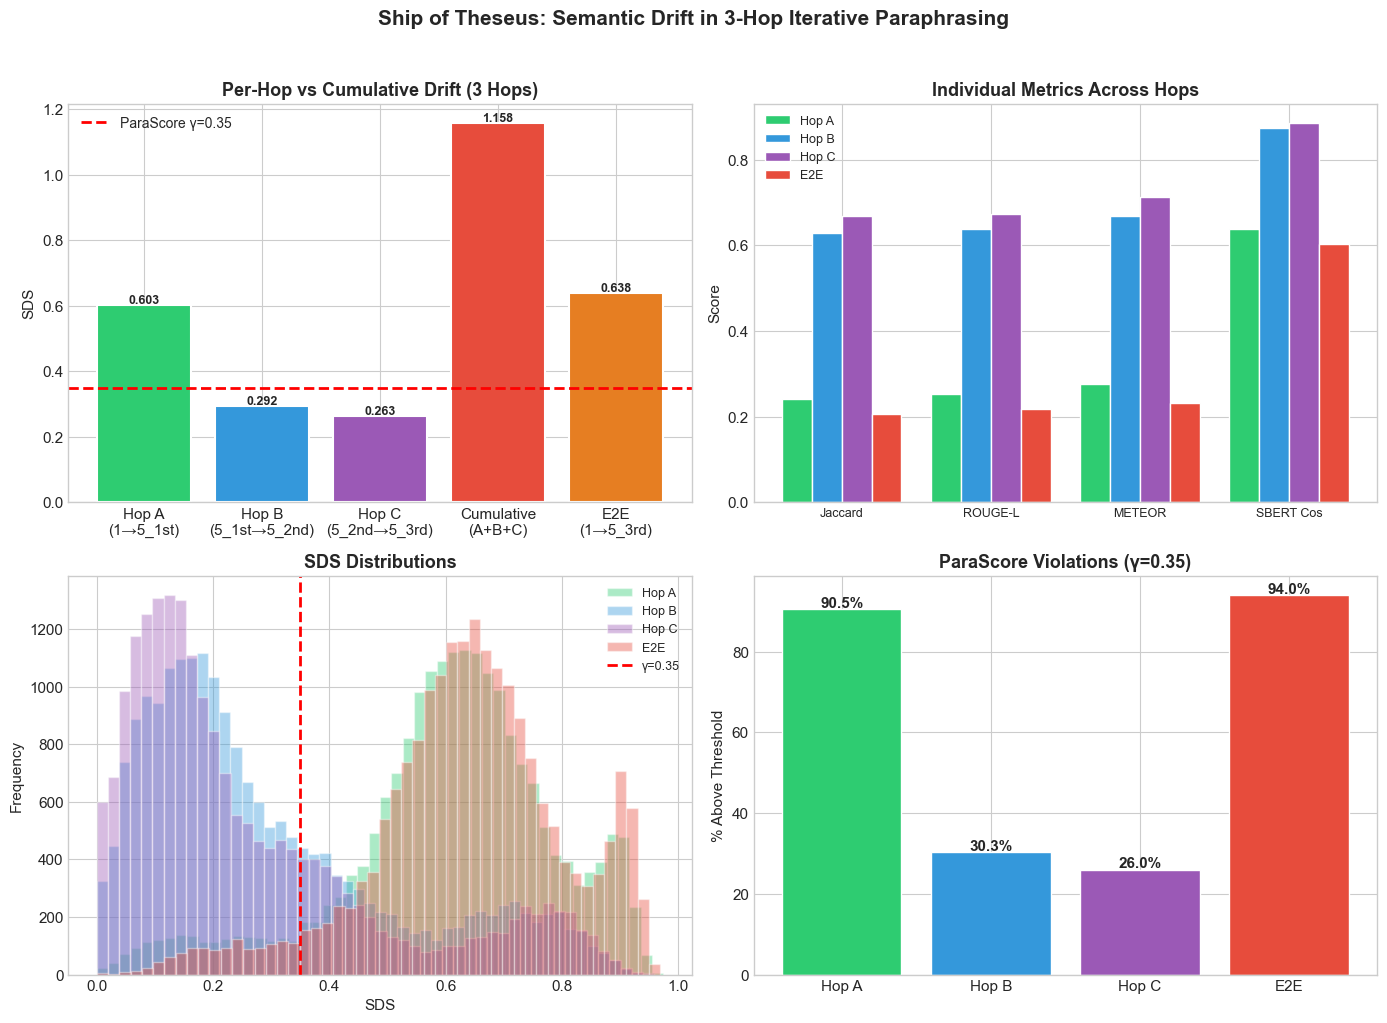

In [23]:
# 7C: MAIN FIGURE — 4-panel Boiling Frog
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Cumulative bar chart (NOW WITH 3 HOPS)
ax = axes[0, 0]
stages = ['Hop A\n(1→5_1st)', 'Hop B\n(5_1st→5_2nd)', 'Hop C\n(5_2nd→5_3rd)', 'Cumulative\n(A+B+C)', 'E2E\n(1→5_3rd)']
values = [hop_a, hop_b, hop_c, cumulative, e2e]
colors_bar = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#e67e22']
bars = ax.bar(stages, values, color=colors_bar, edgecolor='white', linewidth=1.5)
ax.axhline(y=γ, color='red', linestyle='--', linewidth=2, label=f'ParaScore γ={γ}')
ax.set_ylabel('SDS', fontsize=11)
ax.set_title('Per-Hop vs Cumulative Drift (3 Hops)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
for bar, val in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# Top-right: Individual metrics across hops
ax = axes[0, 1]
x = np.arange(len(metric_names))
w = 0.2
for i, (hop, color, label) in enumerate([('hop_a','#2ecc71','Hop A'), ('hop_b','#3498db','Hop B'),
                                           ('hop_c','#9b59b6','Hop C'), ('e2e','#e74c3c','E2E')]):
    vals = [df[f'{m}_{hop}'].mean() for m in metric_names]
    ax.bar(x + i*w, vals, w, label=label, color=color, edgecolor='white')
ax.set_xticks(x + 1.5*w)
ax.set_xticklabels([metric_labels[m] for m in metric_names], fontsize=9)
ax.set_ylabel('Score'); ax.set_title('Individual Metrics Across Hops', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

# Bottom-left: SDS distributions
ax = axes[1, 0]
for hop, color, label in [('hop_a','#2ecc71','Hop A'), ('hop_b','#3498db','Hop B'),
                           ('hop_c','#9b59b6','Hop C'), ('e2e','#e74c3c','E2E')]:
    ax.hist(df[f'SDS_{hop}'], bins=50, alpha=0.4, color=color, label=label, edgecolor='white')
ax.axvline(x=γ, color='red', linestyle='--', linewidth=2, label=f'γ={γ}')
ax.set_xlabel('SDS'); ax.set_ylabel('Frequency')
ax.set_title('SDS Distributions', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

# Bottom-right: Threshold violations
ax = axes[1, 1]
pct = {
    'Hop A': (df['SDS_hop_a'] > γ).mean() * 100,
    'Hop B': (df['SDS_hop_b'] > γ).mean() * 100,
    'Hop C': (df['SDS_hop_c'] > γ).mean() * 100,
    'E2E': (df['SDS_e2e'] > γ).mean() * 100,
}
bars = ax.bar(pct.keys(), pct.values(), color=['#2ecc71','#3498db','#9b59b6','#e74c3c'], edgecolor='white')
ax.set_ylabel('% Above Threshold')
ax.set_title(f'ParaScore Violations (γ={γ})', fontsize=13, fontweight='bold')
for bar, val in zip(bars, pct.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

fig.suptitle('Ship of Theseus: Semantic Drift in 3-Hop Iterative Paraphrasing', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(Path(CFG.output_dir) / 'fig_boiling_frog_3hop.png', dpi=200, bbox_inches='tight')
plt.show()

📊 CROSS-MODEL COMPARISON

🔴 HIGHEST drift: dipper(high) (E2E SDS = 0.8893)
🟢 LOWEST drift:  pegasus(slight) (E2E SDS = 0.5435)

                 SDS_hop_a  SDS_hop_b  SDS_hop_c  SDS_e2e  sbert_e2e  jaccard_e2e  rouge_e2e  meteor_e2e  n_records  cumulative
model                                                                                                                          
dipper(high)        0.8532     0.7352     0.7473   0.8893     0.0845       0.0798     0.0937      0.0894       2509      2.3357
dipper              0.6266     0.4256     0.3950   0.6766     0.5847       0.1647     0.1593      0.1898       3014      1.4472
chatgpt             0.6109     0.2289     0.2210   0.6249     0.6909       0.1568     0.1769      0.1804       3018      1.0608
pegasus(full)       0.5756     0.2066     0.1587   0.6157     0.6564       0.2316     0.2382      0.2419       3019      0.9409
dipper(low)         0.5465     0.1991     0.1618   0.5787     0.6965       0.2516     0.2594      0.2859

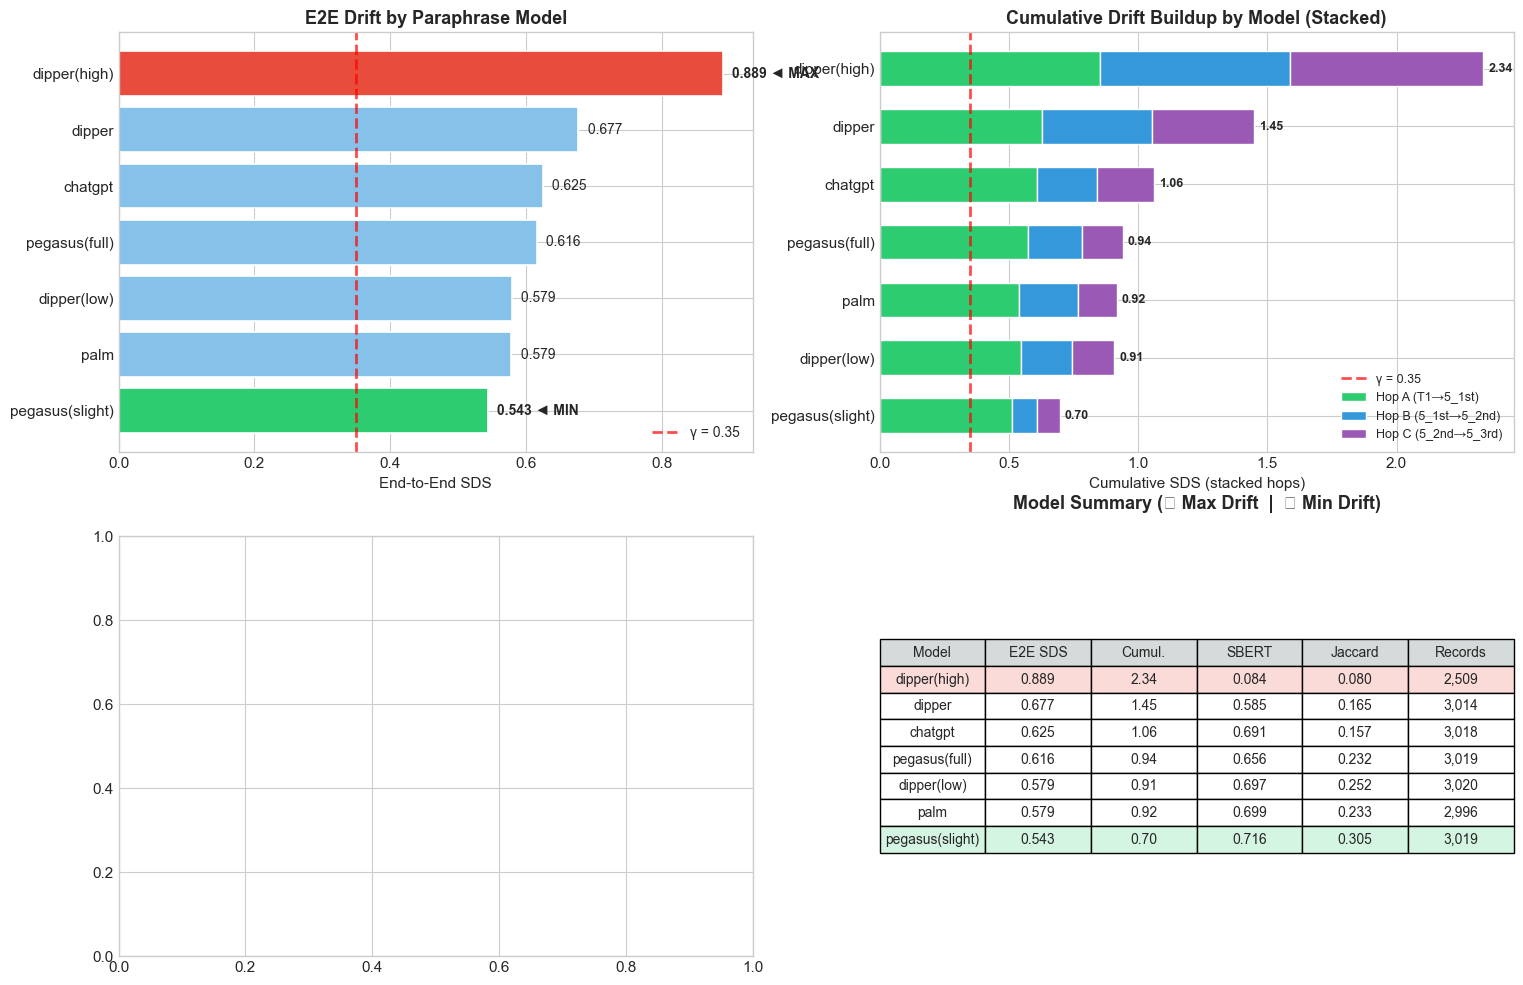

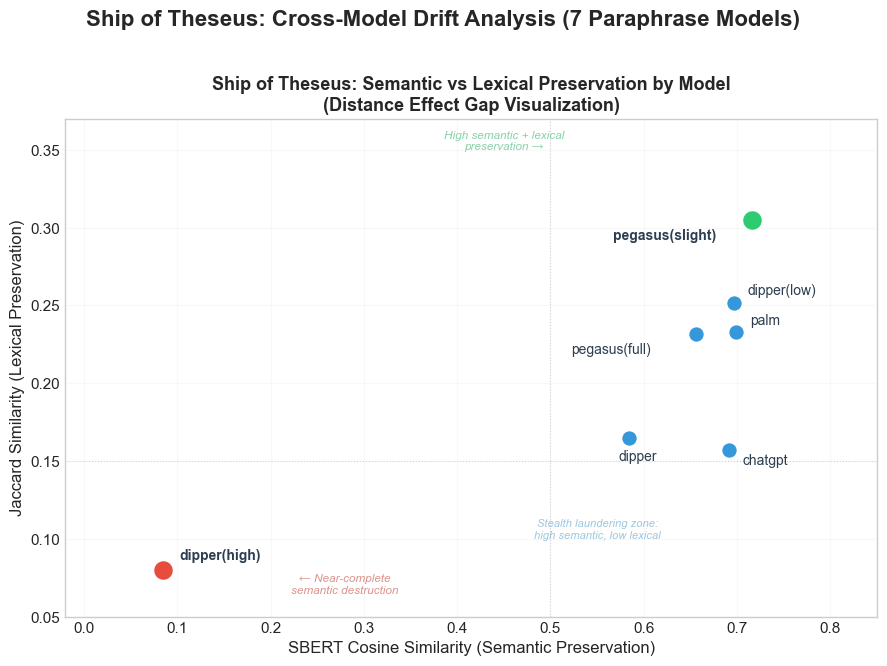

20:38:15 | INFO    | Saved: fig_cross_model_comparison.png
INFO:boiling_frog_v2:Saved: fig_cross_model_comparison.png


In [24]:
# 7D: CROSS-MODEL COMPARISON — Which paraphrase model causes most drift?
print(f"{'='*60}")
print("📊 CROSS-MODEL COMPARISON")
print(f"{'='*60}")

model_drift = df.groupby('model').agg(
    SDS_hop_a=('SDS_hop_a', 'mean'),
    SDS_hop_b=('SDS_hop_b', 'mean'),
    SDS_hop_c=('SDS_hop_c', 'mean'),
    SDS_e2e=('SDS_e2e', 'mean'),
    sbert_e2e=('sbert_cosine_e2e', 'mean'),
    jaccard_e2e=('jaccard_e2e', 'mean'),
    rouge_e2e=('rouge_l_e2e', 'mean'),
    meteor_e2e=('meteor_e2e', 'mean'),
    n_records=('SDS_e2e', 'count')
).round(4)
model_drift['cumulative'] = (model_drift['SDS_hop_a'] + model_drift['SDS_hop_b'] + model_drift['SDS_hop_c']).round(4)
model_drift = model_drift.sort_values('SDS_e2e', ascending=False)

# Highlight max and min
max_model = model_drift['SDS_e2e'].idxmax()
min_model = model_drift['SDS_e2e'].idxmin()

print(f"\n🔴 HIGHEST drift: {max_model} (E2E SDS = {model_drift.loc[max_model, 'SDS_e2e']:.4f})")
print(f"🟢 LOWEST drift:  {min_model} (E2E SDS = {model_drift.loc[min_model, 'SDS_e2e']:.4f})")
print(f"\n{model_drift.to_string()}")

# ── FIGURE: 2×2 Cross-Model Panel ──
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── Top-left: E2E SDS by model (horizontal, sorted, max/min highlighted) ──
ax = axes[0, 0]
sorted_models = model_drift['SDS_e2e'].sort_values(ascending=True)
bar_colors = []
for m in sorted_models.index:
    if m == max_model:
        bar_colors.append('#e74c3c')   # Red for highest
    elif m == min_model:
        bar_colors.append('#2ecc71')   # Green for lowest
    else:
        bar_colors.append('#85c1e9')   # Light blue for others

bars = ax.barh(range(len(sorted_models)), sorted_models.values, color=bar_colors, edgecolor='white', linewidth=1.2)
ax.set_yticks(range(len(sorted_models)))
ax.set_yticklabels(sorted_models.index, fontsize=11)
ax.axvline(x=γ, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'γ = {γ}')

# Annotate values
for i, (model, val) in enumerate(sorted_models.items()):
    label = f' {val:.3f}'
    if model == max_model:
        label += ' ◄ MAX'
    elif model == min_model:
        label += ' ◄ MIN'
    ax.text(val + 0.008, i, label, va='center', fontsize=10, fontweight='bold' if model in [max_model, min_model] else 'normal')

ax.set_xlabel('End-to-End SDS', fontsize=11)
ax.set_title('E2E Drift by Paraphrase Model', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')

# ── Top-right: Stacked hop-by-hop per model (shows cumulative buildup) ──
ax = axes[0, 1]
models_sorted = model_drift.sort_values('cumulative', ascending=True).index
y_pos = np.arange(len(models_sorted))

hop_a_vals = model_drift.loc[models_sorted, 'SDS_hop_a'].values
hop_b_vals = model_drift.loc[models_sorted, 'SDS_hop_b'].values
hop_c_vals = model_drift.loc[models_sorted, 'SDS_hop_c'].values

ax.barh(y_pos, hop_a_vals, height=0.6, color='#2ecc71', edgecolor='white', label='Hop A (T1→5_1st)')
ax.barh(y_pos, hop_b_vals, height=0.6, left=hop_a_vals, color='#3498db', edgecolor='white', label='Hop B (5_1st→5_2nd)')
ax.barh(y_pos, hop_c_vals, height=0.6, left=hop_a_vals + hop_b_vals, color='#9b59b6', edgecolor='white', label='Hop C (5_2nd→5_3rd)')

# Annotate cumulative total
for i, m in enumerate(models_sorted):
    total = model_drift.loc[m, 'cumulative']
    ax.text(total + 0.02, i, f'{total:.2f}', va='center', fontsize=9, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(models_sorted, fontsize=11)
ax.axvline(x=γ, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'γ = {γ}')
ax.set_xlabel('Cumulative SDS (stacked hops)', fontsize=11)
ax.set_title('Cumulative Drift Buildup by Model (Stacked)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')

# ── FIGURE: Scatter plot only (panels 1,2,4 redundant with Table 4) ──
fig, ax = plt.subplots(figsize=(9, 6.5))

label_offsets = {
    'dipper(high)': (12, 8),
    'dipper': (-8, -16),
    'dipper(low)': (10, 6),
    'chatgpt': (10, -10),
    'pegasus(full)': (-90, -14),
    'pegasus(slight)': (-100, -14),
    'palm': (10, 6),
}

for m in model_drift.index:
    row = model_drift.loc[m]
    if m == max_model:
        color, size, zorder = '#e74c3c', 220, 10
    elif m == min_model:
        color, size, zorder = '#2ecc71', 220, 10
    else:
        color, size, zorder = '#3498db', 140, 5
    
    ax.scatter(row['sbert_e2e'], row['jaccard_e2e'], s=size, c=color, 
               edgecolors='white', linewidth=1.5, zorder=zorder)
    
    ox, oy = label_offsets.get(m, (10, 6))
    fontw = 'bold' if m in [max_model, min_model] else 'normal'
    ax.annotate(m, (row['sbert_e2e'], row['jaccard_e2e']),
                textcoords="offset points", xytext=(ox, oy), 
                fontsize=10, fontweight=fontw, color='#2c3e50')

ax.set_xlabel('SBERT Cosine Similarity (Semantic Preservation)', fontsize=12)
ax.set_ylabel('Jaccard Similarity (Lexical Preservation)', fontsize=12)
ax.set_title('Ship of Theseus: Semantic vs Lexical Preservation by Model\n(Distance Effect Gap Visualization)', 
             fontsize=13, fontweight='bold')

ax.axhline(y=0.15, color='gray', linestyle=':', alpha=0.3, linewidth=0.8)
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.3, linewidth=0.8)

ax.annotate('High semantic + lexical\npreservation →', xy=(0.45, 0.35), fontsize=8.5, 
            color='#27ae60', alpha=0.55, ha='center', style='italic')
ax.annotate('← Near-complete\nsemantic destruction', xy=(0.28, 0.065), fontsize=8.5,
            color='#c0392b', alpha=0.55, ha='center', style='italic')
ax.annotate('Stealth laundering zone:\nhigh semantic, low lexical', xy=(0.55, 0.1), fontsize=8,
            color='#2980b9', alpha=0.45, ha='center', style='italic')

ax.set_xlim(-0.02, 0.85)
ax.set_ylim(0.05, 0.37)
ax.grid(True, alpha=0.12)

# ── Bottom-right: Model summary table as visual ──
ax = axes[1, 1]
ax.axis('off')

table_data = []
for m in model_drift.index:
    row = model_drift.loc[m]
    table_data.append([
        m,
        f"{row['SDS_e2e']:.3f}",
        f"{row['cumulative']:.2f}",
        f"{row['sbert_e2e']:.3f}",
        f"{row['jaccard_e2e']:.3f}",
        f"{int(row['n_records']):,}"
    ])

col_labels = ['Model', 'E2E SDS', 'Cumul.', 'SBERT', 'Jaccard', 'Records']
table = ax.table(cellText=table_data, colLabels=col_labels, loc='center',
                  cellLoc='center', colColours=['#d5dbdb']*6)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

# Highlight max row red, min row green
for j in range(6):
    table[1, j].set_facecolor('#fadbd8')  # Max (first row = highest drift)
    table[len(table_data), j].set_facecolor('#d5f5e3')  # Min (last row)

ax.set_title('Model Summary (🔴 Max Drift  |  🟢 Min Drift)', fontsize=13, fontweight='bold', pad=20)

fig.suptitle('Ship of Theseus: Cross-Model Drift Analysis (7 Paraphrase Models)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(Path(CFG.output_dir) / 'fig_cross_model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
log.info("Saved: fig_cross_model_comparison.png")

📊 CROSS-DOMAIN COMPARISON

🔴 HIGHEST drift: WP (E2E SDS = 0.6943)
🟢 LOWEST drift:  TLDR (E2E SDS = 0.5740)

        SDS_hop_a  SDS_hop_b  SDS_hop_c  SDS_e2e  sbert_e2e  jaccard_e2e  n_records  cumulative
domain                                                                                         
WP         0.6654     0.2880     0.2720   0.6943     0.5298       0.1828       3244      1.2254
CMV        0.6515     0.2721     0.2542   0.6767     0.5471       0.1943       1738      1.1778
ELI5       0.6235     0.2864     0.2708   0.6587     0.5686       0.2034       3208      1.1807
XSUM       0.5767     0.3450     0.2498   0.6333     0.6348       0.2007       3222      1.1715
YELP       0.5865     0.2942     0.2774   0.6245     0.6157       0.2131       3360      1.1581
SCI        0.5894     0.2763     0.2592   0.6097     0.6325       0.2161       3209      1.1249
TLDR       0.5398     0.2697     0.2510   0.5740     0.6745       0.2319       2614      1.0605


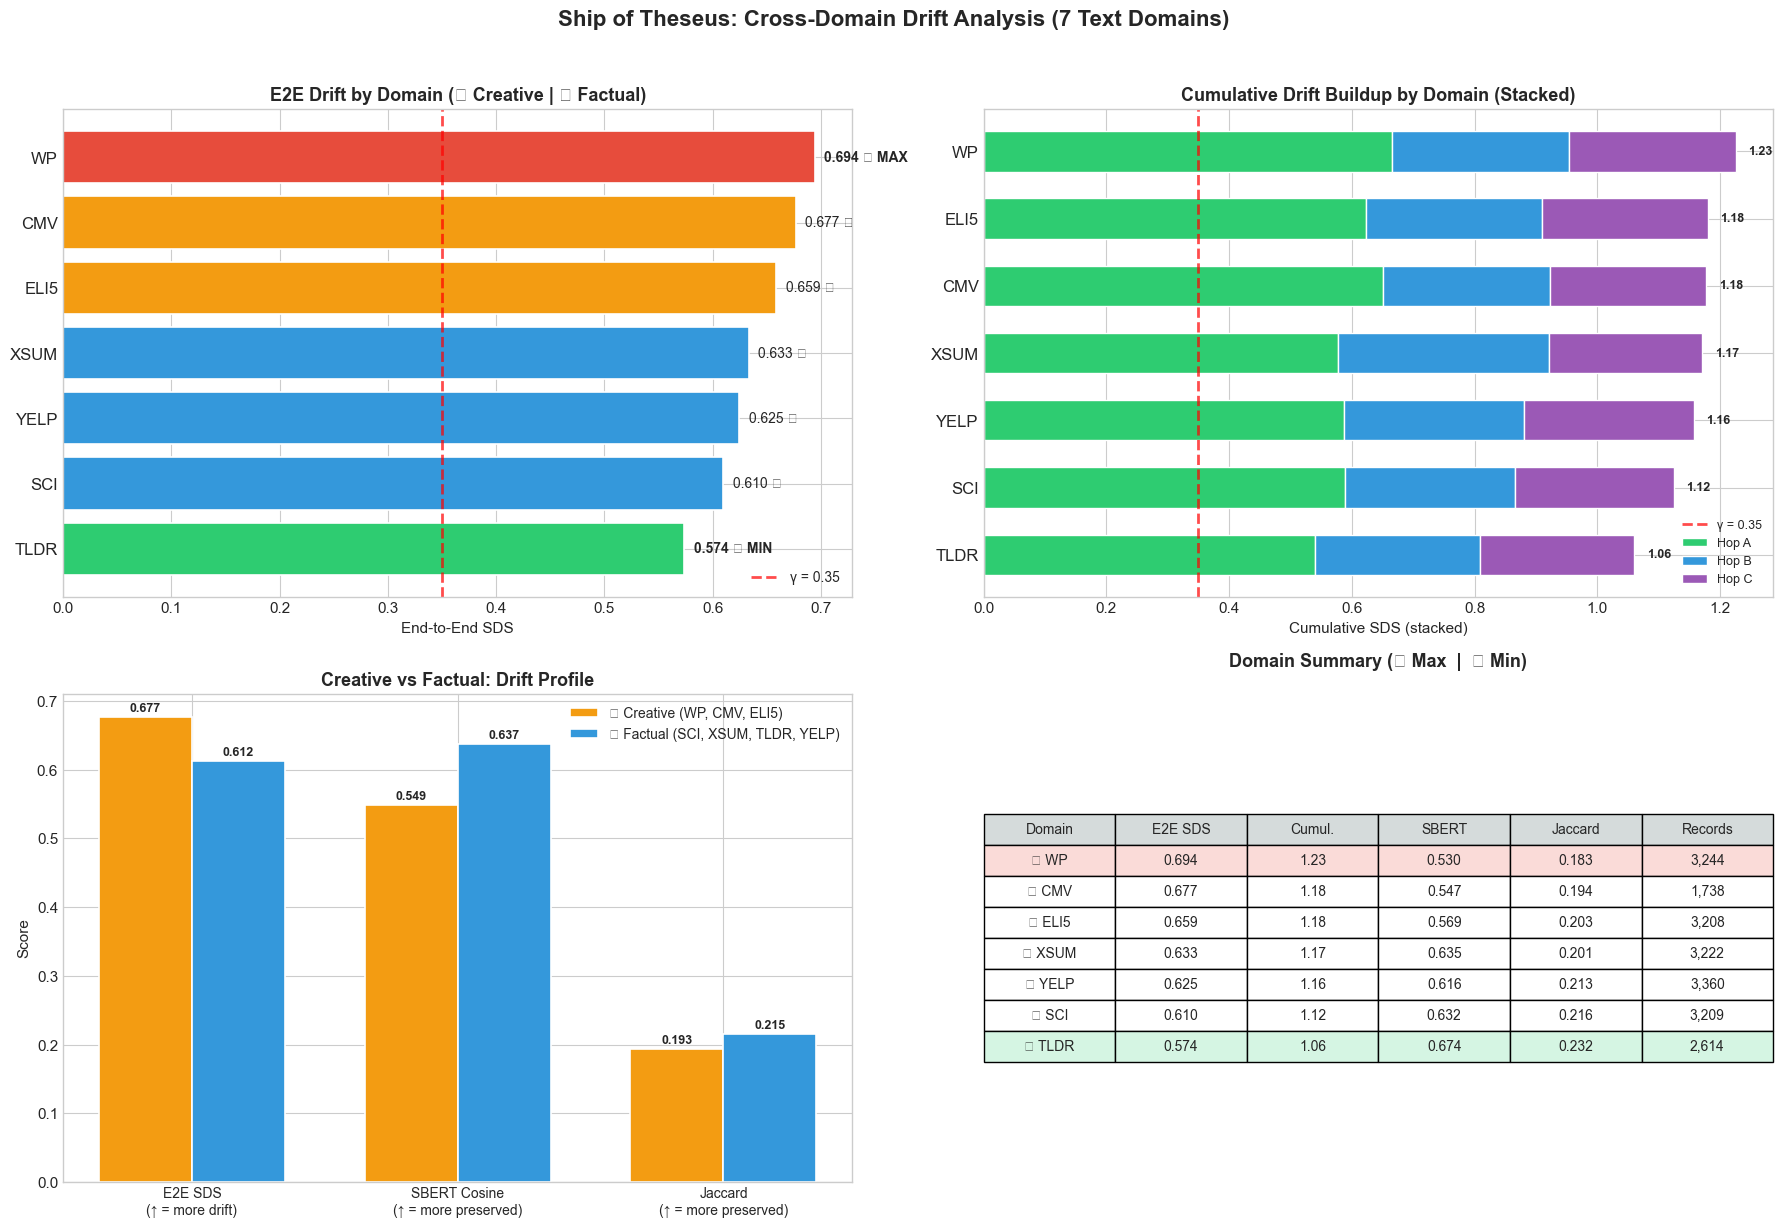

20:38:16 | INFO    | Saved: fig_cross_domain_comparison.png
INFO:boiling_frog_v2:Saved: fig_cross_domain_comparison.png


In [25]:
# 7E: CROSS-DOMAIN COMPARISON
print(f"{'='*60}")
print("📊 CROSS-DOMAIN COMPARISON")
print(f"{'='*60}")

domain_drift = df.groupby('domain').agg(
    SDS_hop_a=('SDS_hop_a', 'mean'),
    SDS_hop_b=('SDS_hop_b', 'mean'),
    SDS_hop_c=('SDS_hop_c', 'mean'),
    SDS_e2e=('SDS_e2e', 'mean'),
    sbert_e2e=('sbert_cosine_e2e', 'mean'),
    jaccard_e2e=('jaccard_e2e', 'mean'),
    n_records=('SDS_e2e', 'count')
).round(4)
domain_drift['cumulative'] = (domain_drift['SDS_hop_a'] + domain_drift['SDS_hop_b'] + domain_drift['SDS_hop_c']).round(4)
domain_drift = domain_drift.sort_values('SDS_e2e', ascending=False)

max_domain = domain_drift['SDS_e2e'].idxmax()
min_domain = domain_drift['SDS_e2e'].idxmin()

print(f"\n🔴 HIGHEST drift: {max_domain} (E2E SDS = {domain_drift.loc[max_domain, 'SDS_e2e']:.4f})")
print(f"🟢 LOWEST drift:  {min_domain} (E2E SDS = {domain_drift.loc[min_domain, 'SDS_e2e']:.4f})")
print(f"\n{domain_drift.to_string()}")

# ── FIGURE: 2×2 Cross-Domain Panel ──
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Domain type classification
creative_domains = {'WP', 'CMV', 'ELI5'}
factual_domains = {'SCI', 'XSUM', 'TLDR', 'YELP'}

# ── Top-left: E2E SDS by domain (color-coded creative vs factual) ──
ax = axes[0, 0]
sorted_domains = domain_drift['SDS_e2e'].sort_values(ascending=True)
bar_colors = []
for d in sorted_domains.index:
    if d == max_domain:
        bar_colors.append('#e74c3c')
    elif d == min_domain:
        bar_colors.append('#2ecc71')
    elif d in creative_domains:
        bar_colors.append('#f39c12')  # Orange for creative
    else:
        bar_colors.append('#3498db')  # Blue for factual

bars = ax.barh(range(len(sorted_domains)), sorted_domains.values, color=bar_colors, edgecolor='white', linewidth=1.2)
ax.set_yticks(range(len(sorted_domains)))
ax.set_yticklabels(sorted_domains.index, fontsize=12)
ax.axvline(x=γ, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'γ = {γ}')

for i, (domain, val) in enumerate(sorted_domains.items()):
    dtype = '🎨' if domain in creative_domains else '📄'
    label = f' {val:.3f} {dtype}'
    if domain == max_domain:
        label += ' MAX'
    elif domain == min_domain:
        label += ' MIN'
    ax.text(val + 0.005, i, label, va='center', fontsize=10,
            fontweight='bold' if domain in [max_domain, min_domain] else 'normal')

ax.set_xlabel('End-to-End SDS', fontsize=11)
ax.set_title('E2E Drift by Domain (🎨 Creative | 📄 Factual)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# ── Top-right: Stacked hop-by-hop per domain ──
ax = axes[0, 1]
domains_sorted = domain_drift.sort_values('cumulative', ascending=True).index
y_pos = np.arange(len(domains_sorted))

ha = domain_drift.loc[domains_sorted, 'SDS_hop_a'].values
hb = domain_drift.loc[domains_sorted, 'SDS_hop_b'].values
hc = domain_drift.loc[domains_sorted, 'SDS_hop_c'].values

ax.barh(y_pos, ha, height=0.6, color='#2ecc71', edgecolor='white', label='Hop A')
ax.barh(y_pos, hb, height=0.6, left=ha, color='#3498db', edgecolor='white', label='Hop B')
ax.barh(y_pos, hc, height=0.6, left=ha + hb, color='#9b59b6', edgecolor='white', label='Hop C')

for i, d in enumerate(domains_sorted):
    total = domain_drift.loc[d, 'cumulative']
    ax.text(total + 0.02, i, f'{total:.2f}', va='center', fontsize=9, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(domains_sorted, fontsize=12)
ax.axvline(x=γ, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'γ = {γ}')
ax.set_xlabel('Cumulative SDS (stacked)', fontsize=11)
ax.set_title('Cumulative Drift Buildup by Domain (Stacked)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')

# ── Bottom-left: Creative vs Factual grouped comparison ──
ax = axes[1, 0]
creative_mean = df[df['domain'].isin(creative_domains)]['SDS_e2e'].mean()
factual_mean = df[df['domain'].isin(factual_domains)]['SDS_e2e'].mean()
creative_sbert = df[df['domain'].isin(creative_domains)]['sbert_cosine_e2e'].mean()
factual_sbert = df[df['domain'].isin(factual_domains)]['sbert_cosine_e2e'].mean()
creative_jaccard = df[df['domain'].isin(creative_domains)]['jaccard_e2e'].mean()
factual_jaccard = df[df['domain'].isin(factual_domains)]['jaccard_e2e'].mean()

x_pos = np.arange(3)
width = 0.35
creative_vals = [creative_mean, creative_sbert, creative_jaccard]
factual_vals = [factual_mean, factual_sbert, factual_jaccard]

bars1 = ax.bar(x_pos - width/2, creative_vals, width, label='🎨 Creative (WP, CMV, ELI5)',
               color='#f39c12', edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x_pos + width/2, factual_vals, width, label='📄 Factual (SCI, XSUM, TLDR, YELP)',
               color='#3498db', edgecolor='white', linewidth=1.2)

ax.set_xticks(x_pos)
ax.set_xticklabels(['E2E SDS\n(↑ = more drift)', 'SBERT Cosine\n(↑ = more preserved)', 'Jaccard\n(↑ = more preserved)'], fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Creative vs Factual: Drift Profile', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

# ── Bottom-right: Domain summary table ──
ax = axes[1, 1]
ax.axis('off')

table_data = []
for d in domain_drift.index:
    row = domain_drift.loc[d]
    dtype = '🎨' if d in creative_domains else '📄'
    table_data.append([
        f"{dtype} {d}",
        f"{row['SDS_e2e']:.3f}",
        f"{row['cumulative']:.2f}",
        f"{row['sbert_e2e']:.3f}",
        f"{row['jaccard_e2e']:.3f}",
        f"{int(row['n_records']):,}"
    ])

col_labels = ['Domain', 'E2E SDS', 'Cumul.', 'SBERT', 'Jaccard', 'Records']
table = ax.table(cellText=table_data, colLabels=col_labels, loc='center',
                  cellLoc='center', colColours=['#d5dbdb']*6)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

# Highlight max/min
for j in range(6):
    table[1, j].set_facecolor('#fadbd8')
    table[len(table_data), j].set_facecolor('#d5f5e3')

ax.set_title('Domain Summary (🔴 Max  |  🟢 Min)', fontsize=13, fontweight='bold', pad=20)

fig.suptitle('Ship of Theseus: Cross-Domain Drift Analysis (7 Text Domains)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(Path(CFG.output_dir) / 'fig_cross_domain_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
log.info("Saved: fig_cross_domain_comparison.png")

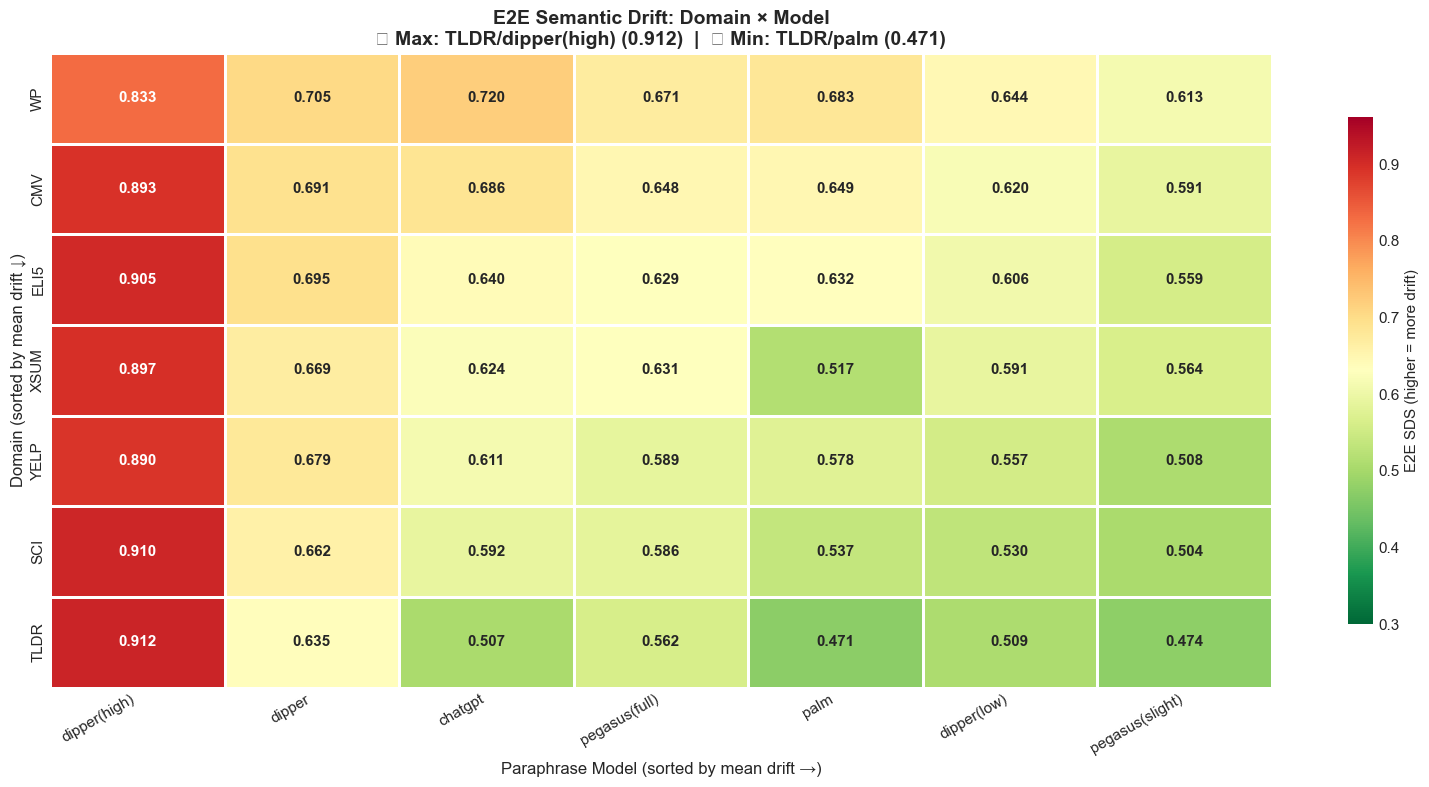

20:38:17 | INFO    | Saved: fig_domain_model_heatmap.png
INFO:boiling_frog_v2:Saved: fig_domain_model_heatmap.png


In [26]:
# 7F: DOMAIN × MODEL HEATMAP
pivot_e2e = df.pivot_table(index='domain', columns='model', values='SDS_e2e', aggfunc='mean')

# Reorder: domains by mean drift (high→low), models by mean drift (high→low)
domain_order = pivot_e2e.mean(axis=1).sort_values(ascending=False).index
model_order = pivot_e2e.mean(axis=0).sort_values(ascending=False).index
pivot_e2e = pivot_e2e.loc[domain_order, model_order]

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pivot_e2e, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax,
            linewidths=0.8, linecolor='white',
            vmin=0.3, vmax=min(1.0, pivot_e2e.max().max() + 0.05),
            annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'label': 'E2E SDS (higher = more drift)', 'shrink': 0.8})

# Mark global max and min
global_max = pivot_e2e.stack().idxmax()
global_min = pivot_e2e.stack().idxmin()

ax.set_title(f'E2E Semantic Drift: Domain × Model\n'
             f'🔴 Max: {global_max[0]}/{global_max[1]} ({pivot_e2e.loc[global_max]:.3f})  |  '
             f'🟢 Min: {global_min[0]}/{global_min[1]} ({pivot_e2e.loc[global_min]:.3f})',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Domain (sorted by mean drift ↓)', fontsize=12)
ax.set_xlabel('Paraphrase Model (sorted by mean drift →)', fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig(Path(CFG.output_dir) / 'fig_domain_model_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
log.info("Saved: fig_domain_model_heatmap.png")

Spearman Correlation Matrix (E2E):
           Jaccard  ROUGE-L  METEOR  SBERT Cos  Edit Dist    SDS
Jaccard      1.000    0.882   0.825      0.702     -0.753 -0.804
ROUGE-L      0.882    1.000   0.818      0.698     -0.842 -0.815
METEOR       0.825    0.818   1.000      0.630     -0.734 -0.767
SBERT Cos    0.702    0.698   0.630      1.000     -0.531 -0.973
Edit Dist   -0.753   -0.842  -0.734     -0.531      1.000  0.644
SDS         -0.804   -0.815  -0.767     -0.973      0.644  1.000

Exported to ./outputs/spearman_correlation_matrix.csv


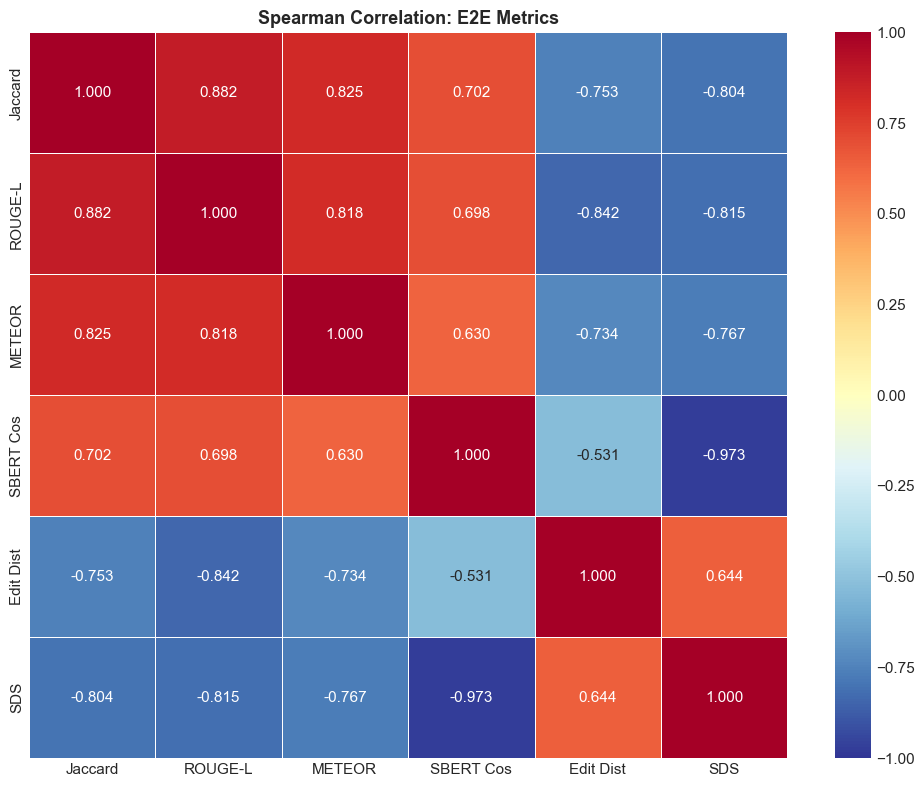

In [27]:
# 7G: CORRELATION HEATMAP
corr_cols = [f'{m}_e2e' for m in ['jaccard', 'rouge_l', 'meteor', 'sbert_cosine', 'edit_dist']] + ['SDS_e2e']
corr_matrix = df[corr_cols].corr(method='spearman')

corr_matrix_labeled = corr_matrix.copy()
corr_matrix_labeled.index = ['Jaccard', 'ROUGE-L', 'METEOR', 'SBERT Cos', 'Edit Dist', 'SDS']
corr_matrix_labeled.columns = corr_matrix_labeled.index
corr_matrix_labeled.to_csv(Path(CFG.output_dir) / 'spearman_correlation_matrix.csv')
print("Spearman Correlation Matrix (E2E):")
print(corr_matrix_labeled.round(3).to_string())
print(f"\nExported to {CFG.output_dir}/spearman_correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(10, 8))
labels = ['Jaccard', 'ROUGE-L', 'METEOR', 'SBERT Cos', 'Edit Dist', 'SDS']
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r', ax=ax,
            xticklabels=labels, yticklabels=labels, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Spearman Correlation: E2E Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(Path(CFG.output_dir) / 'fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 7H: Cross-Dataset Hyper View — PADBen vs Ship of Theseus

Comparing drift behavior across both datasets side-by-side. PADBen results are loaded directly from the sentence-level pipeline's `drift_results.csv` output — no hardcoded values. This provides the "hyper view" comparing sentence-level paraphrase attacks (PADBen) against paragraph-level iterative rewriting (Ship of Theseus).

20:38:17 | INFO    | Loaded PADBen results: 16,232 records from ..\BoilingFrog_SemanticDrift_Pipeline\outputs\drift_results.csv
INFO:boiling_frog_v2:Loaded PADBen results: 16,232 records from ..\BoilingFrog_SemanticDrift_Pipeline\outputs\drift_results.csv


📊 CROSS-DATASET HYPER VIEW: PADBen vs Ship of Theseus
✅ PADBen data loaded from CSV: 16,232 records
   E2E SDS: 0.3979 | Cumulative: 0.6613
   Sources: ['mrpc', 'hlpc', 'paws']

   Per-source E2E SDS:
     mrpc: SDS=0.4483 (n=3,750)
     hlpc: SDS=0.4053 (n=380)
     paws: SDS=0.3821 (n=12,102)

Metric                                  PADBen             SoT      Delta
------------------------------------------------------------------------
Records                                 16,232          20,595     +4,363
E2E SDS                                 0.3979          0.6379    +0.2399
Cumulative SDS                          0.6613          1.1584    +0.4971
Hop A SDS                               0.3403          0.6032    +0.2629
Hop B SDS                               0.3210          0.2922    -0.0288
SBERT Cosine (E2E)                      0.8686          0.6021    -0.2665
Jaccard (E2E)                           0.3929          0.2061    -0.1868
METEOR (E2E)                          

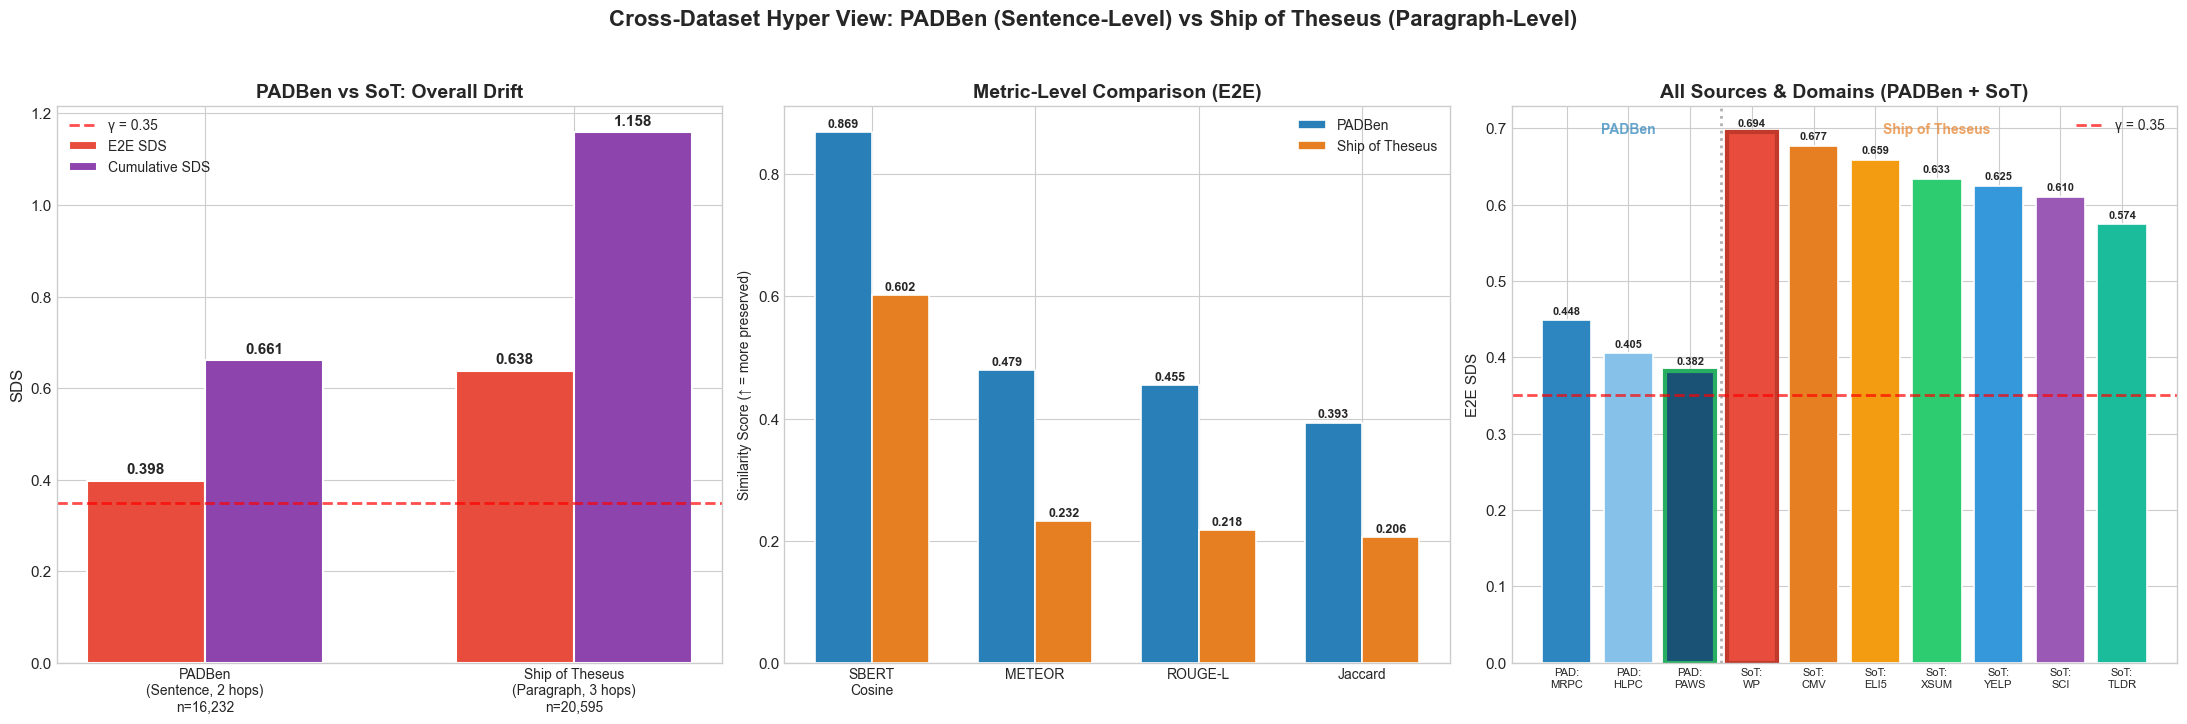

20:38:18 | INFO    | Saved: fig_cross_dataset_comparison.png
INFO:boiling_frog_v2:Saved: fig_cross_dataset_comparison.png


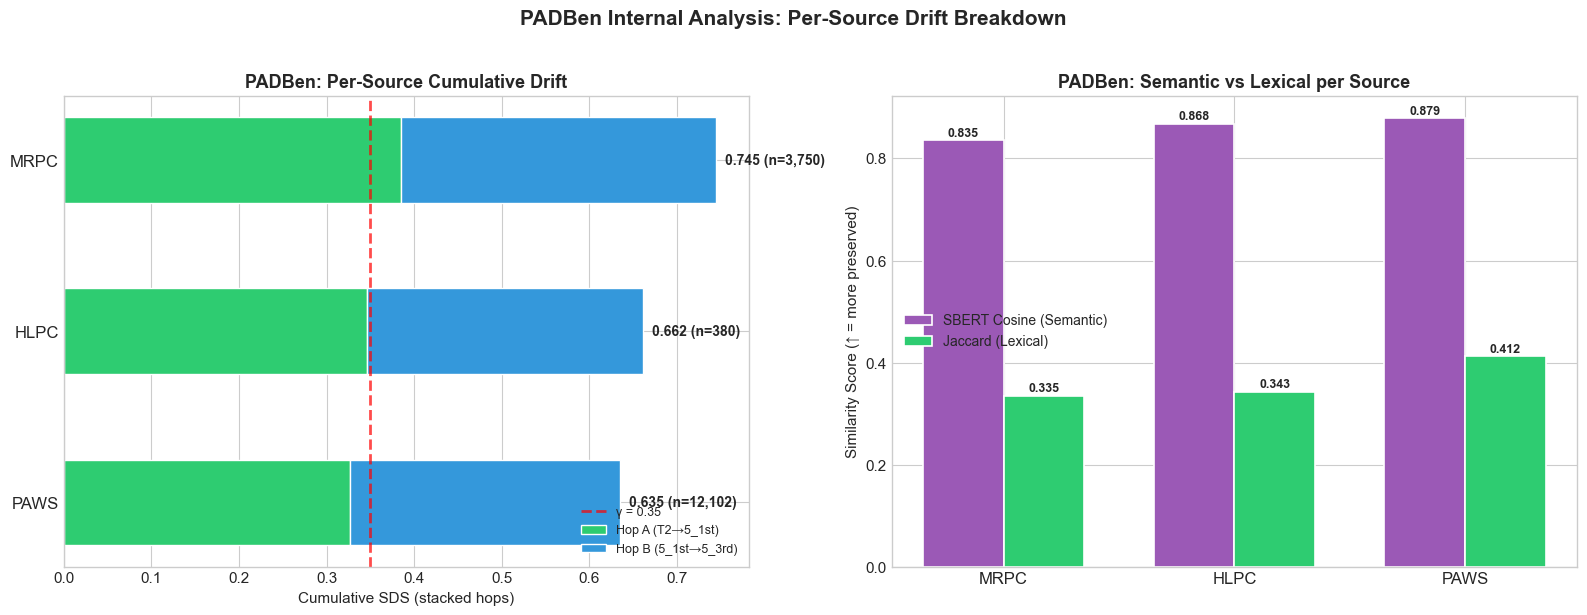

20:38:18 | INFO    | Saved: fig_padben_per_source.png
INFO:boiling_frog_v2:Saved: fig_padben_per_source.png



📊 KEY CROSS-DATASET FINDINGS
  1. Boiling Frog confirmed in BOTH datasets:
     PADBen:  cumulative = 0.661 (1.9× γ)
     SoT:     cumulative = 1.158 (3.3× γ)

  2. SoT shows higher E2E drift (0.638 vs 0.398)
     → Text length effect: paragraphs (~274 tok) vs sentences (~20 tok)
     → More surface area for lexical substitution in longer texts

  3. Lexical erosion > semantic drift in BOTH:
     PADBen: SBERT=0.869 vs Jaccard=0.393 (gap=0.476)
     SoT:    SBERT=0.602 vs Jaccard=0.206 (gap=0.396)

  4. Attack types tested:
     PADBen: Plagiarism Evasion (LLM text → paraphrased)
     SoT:    Authorship Obfuscation (Human text → paraphrased)
     → Boiling Frog is UNIVERSAL across both attack scenarios

  5. PADBen per-source breakdown:
     MRPC: E2E SDS=0.4483, SBERT=0.8353, Jaccard=0.3349 (n=3,750)
     HLPC: E2E SDS=0.4053, SBERT=0.8677, Jaccard=0.3429 (n=380)
     PAWS: E2E SDS=0.3821, SBERT=0.8789, Jaccard=0.4125 (n=12,102)


In [28]:
# ============================================================================
# 7H: CROSS-DATASET HYPER VIEW — PADBen vs Ship of Theseus
# ============================================================================
print(f"{'='*70}")
print("📊 CROSS-DATASET HYPER VIEW: PADBen vs Ship of Theseus")
print(f"{'='*70}")

# ── PADBen results — loaded from actual pipeline output (NOT hardcoded) ──
padben_results_path = Path('../BoilingFrog_SemanticDrift_Pipeline/outputs/drift_results.csv')
# ^^^ Adjust this path based on your folder structure

if not padben_results_path.exists():
    # Try alternative paths
    alt_paths = [
        Path('../../BoilingFrog_SemanticDrift_Pipeline/outputs/drift_results.csv'),
        Path('../padben/outputs/drift_results.csv'),
        Path('./padben_drift_results.csv'),
    ]
    for alt in alt_paths:
        if alt.exists():
            padben_results_path = alt
            break
    else:
        raise FileNotFoundError(
            f"PADBen drift_results.csv not found. Tried:\n"
            f"  {padben_results_path}\n" +
            "\n".join(f"  {p}" for p in alt_paths) +
            "\n\nRun the PADBen pipeline first, or copy drift_results.csv here."
        )

df_padben = pd.read_csv(padben_results_path)
log.info(f"Loaded PADBen results: {len(df_padben):,} records from {padben_results_path}")

# Build PADBen summary from actual data
padben = {
    'dataset': 'PADBen',
    'text_level': 'Sentence',
    'n_records': len(df_padben),
    'chain': 'T2 → T5-1st → T5-3rd (2 hops)',
    'attack_type': 'Plagiarism Evasion',
    'hop_a_sds': df_padben['SDS_hop_a'].mean(),
    'hop_b_sds': df_padben['SDS_hop_b'].mean(),
    'hop_c_sds': None,
    'cumulative': df_padben['SDS_hop_a'].mean() + df_padben['SDS_hop_b'].mean(),
    'e2e': df_padben['SDS_e2e'].mean(),
    'anchor': df_padben['SDS_anchor'].mean(),
    'sbert_e2e': df_padben['sbert_cosine_e2e'].mean(),
    'jaccard_e2e': df_padben['jaccard_e2e'].mean(),
    'meteor_e2e': df_padben['meteor_e2e'].mean(),
    'rouge_e2e': df_padben['rouge_l_e2e'].mean(),
}

# Per-source breakdown (PAWS, MRPC, HLPC)
padben_source_drift = df_padben.groupby('dataset_source').agg(
    SDS_e2e=('SDS_e2e', 'mean'),
    SDS_anchor=('SDS_anchor', 'mean'),
    sbert_e2e=('sbert_cosine_e2e', 'mean'),
    jaccard_e2e=('jaccard_e2e', 'mean'),
    n_records=('SDS_e2e', 'count')
).round(4).sort_values('SDS_e2e', ascending=False)

padben['sources'] = padben_source_drift

print(f"✅ PADBen data loaded from CSV: {padben['n_records']:,} records")
print(f"   E2E SDS: {padben['e2e']:.4f} | Cumulative: {padben['cumulative']:.4f}")
print(f"   Sources: {list(padben_source_drift.index)}")
print(f"\n   Per-source E2E SDS:")
for src, row in padben_source_drift.iterrows():
    print(f"     {src}: SDS={row['SDS_e2e']:.4f} (n={int(row['n_records']):,})")

# ── SoT results (computed live in this notebook) ──
sot_e2e_mean = df['SDS_e2e'].mean()
sot_sbert = df['sbert_cosine_e2e'].mean()
sot_jaccard = df['jaccard_e2e'].mean()
sot_meteor = df['meteor_e2e'].mean()
sot_rouge = df['rouge_l_e2e'].mean()

sot = {
    'dataset': 'Ship of Theseus',
    'text_level': 'Paragraph',
    'n_records': len(df),
    'chain': 'T1 → T5-1st → T5-2nd → T5-3rd (3 hops)',
    'attack_type': 'Authorship Obfuscation',
    'hop_a_sds': df['SDS_hop_a'].mean(),
    'hop_b_sds': df['SDS_hop_b'].mean(),
    'hop_c_sds': df['SDS_hop_c'].mean(),
    'cumulative': df['SDS_hop_a'].mean() + df['SDS_hop_b'].mean() + df['SDS_hop_c'].mean(),
    'e2e': sot_e2e_mean,
    'sbert_e2e': sot_sbert,
    'jaccard_e2e': sot_jaccard,
    'meteor_e2e': sot_meteor,
    'rouge_e2e': sot_rouge,
}

# ── Print comparison table ──
print(f"\n{'='*70}")
print(f"{'Metric':<30} {'PADBen':>15} {'SoT':>15} {'Delta':>10}")
print("-" * 72)
for label, pk, sk in [
    ('Records', 'n_records', 'n_records'),
    ('E2E SDS', 'e2e', 'e2e'),
    ('Cumulative SDS', 'cumulative', 'cumulative'),
    ('Hop A SDS', 'hop_a_sds', 'hop_a_sds'),
    ('Hop B SDS', 'hop_b_sds', 'hop_b_sds'),
    ('SBERT Cosine (E2E)', 'sbert_e2e', 'sbert_e2e'),
    ('Jaccard (E2E)', 'jaccard_e2e', 'jaccard_e2e'),
    ('METEOR (E2E)', 'meteor_e2e', 'meteor_e2e'),
    ('ROUGE-L (E2E)', 'rouge_e2e', 'rouge_e2e'),
]:
    pv = padben[pk]
    sv = sot[sk]
    if pv is None or sv is None:
        continue
    if isinstance(pv, int):
        print(f"{label:<30} {pv:>15,} {sv:>15,} {sv-pv:>+10,}")
    else:
        print(f"{label:<30} {pv:>15.4f} {sv:>15.4f} {sv-pv:>+10.4f}")

γ = CFG.parascore_threshold

# ══════════════════════════════════════════════════════════════════════════
# FIGURE 1: Overall PADBen vs SoT (dual bar comparison)
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── Panel 1: Overall E2E and Cumulative comparison ──
ax = axes[0]
x = np.arange(2)
width = 0.32
e2e_vals = [padben['e2e'], sot['e2e']]
cum_vals = [padben['cumulative'], sot['cumulative']]

bars1 = ax.bar(x - width/2, e2e_vals, width, label='E2E SDS',
               color='#e74c3c', edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, cum_vals, width, label='Cumulative SDS',
               color='#8e44ad', edgecolor='white', linewidth=1.5)
ax.axhline(y=γ, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'γ = {γ}')

ax.set_xticks(x)
ax.set_xticklabels([f'PADBen\n(Sentence, 2 hops)\nn={padben["n_records"]:,}',
                     f'Ship of Theseus\n(Paragraph, 3 hops)\nn={sot["n_records"]:,}'], fontsize=10)
ax.set_ylabel('SDS', fontsize=12)
ax.set_title('PADBen vs SoT: Overall Drift', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                f'{bar.get_height():.3f}', ha='center', fontsize=11, fontweight='bold')

# ── Panel 2: Individual metrics side-by-side ──
ax = axes[1]
metric_labels_cmp = ['SBERT\nCosine', 'METEOR', 'ROUGE-L', 'Jaccard']
padben_metric_vals = [padben['sbert_e2e'], padben['meteor_e2e'], padben['rouge_e2e'], padben['jaccard_e2e']]
sot_metric_vals = [sot['sbert_e2e'], sot['meteor_e2e'], sot['rouge_e2e'], sot['jaccard_e2e']]

x = np.arange(len(metric_labels_cmp))
width = 0.35
bars1 = ax.bar(x - width/2, padben_metric_vals, width, label='PADBen',
               color='#2980b9', edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + width/2, sot_metric_vals, width, label='Ship of Theseus',
               color='#e67e22', edgecolor='white', linewidth=1.2)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels_cmp, fontsize=10)
ax.set_ylabel('Similarity Score (↑ = more preserved)', fontsize=10)
ax.set_title('Metric-Level Comparison (E2E)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

# ── Panel 3: All sources — PADBen per-source + SoT per-domain on same axis ──
ax = axes[2]

all_labels = []
all_values = []
all_colors = []

# PADBen per-source (from actual CSV data)
padben_colors = {'paws': '#1a5276', 'mrpc': '#2e86c1', 'hlpc': '#85c1e9'}
for src, row in padben_source_drift.iterrows():
    all_labels.append(f'PAD:\n{src.upper()}')
    all_values.append(row['SDS_e2e'])
    all_colors.append(padben_colors.get(src.lower(), '#2980b9'))

# SoT per-domain
sot_domain_colors = {
    'WP': '#e74c3c', 'CMV': '#e67e22', 'ELI5': '#f39c12',
    'XSUM': '#2ecc71', 'YELP': '#3498db', 'SCI': '#9b59b6', 'TLDR': '#1abc9c'
}
for d in domain_drift.sort_values('SDS_e2e', ascending=False).index:
    all_labels.append(f'SoT:\n{d}')
    all_values.append(domain_drift.loc[d, 'SDS_e2e'])
    all_colors.append(sot_domain_colors.get(d, '#95a5a6'))

bars = ax.bar(range(len(all_labels)), all_values, color=all_colors, edgecolor='white', linewidth=1.2)
ax.axhline(y=γ, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'γ = {γ}')
ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, fontsize=8, rotation=0)
ax.set_ylabel('E2E SDS', fontsize=11)
ax.set_title('All Sources & Domains (PADBen + SoT)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)

# Divider line between PADBen sources and SoT domains
n_padben_sources = len(padben_source_drift)
ax.axvline(x=n_padben_sources - 0.5, color='gray', linestyle=':', linewidth=2, alpha=0.6)
ax.text(n_padben_sources / 2 - 0.5, ax.get_ylim()[1] * 0.95, 'PADBen',
        ha='center', fontsize=10, fontweight='bold', color='#2980b9', alpha=0.7)
ax.text(n_padben_sources + len(domain_drift) / 2 - 0.5, ax.get_ylim()[1] * 0.95, 'Ship of Theseus',
        ha='center', fontsize=10, fontweight='bold', color='#e67e22', alpha=0.7)

# Annotate values
for bar, val in zip(bars, all_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

# Highlight overall max and min across ALL sources/domains
max_idx = np.argmax(all_values)
min_idx = np.argmin(all_values)
bars[max_idx].set_edgecolor('#c0392b')
bars[max_idx].set_linewidth(3)
bars[min_idx].set_edgecolor('#27ae60')
bars[min_idx].set_linewidth(3)

fig.suptitle('Cross-Dataset Hyper View: PADBen (Sentence-Level) vs Ship of Theseus (Paragraph-Level)',
             fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(Path(CFG.output_dir) / 'fig_cross_dataset_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
log.info("Saved: fig_cross_dataset_comparison.png")

# ══════════════════════════════════════════════════════════════════════════
# FIGURE 2: PADBen internal — per-source stacked + dual bar (like SoT has)
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: PADBen per-source E2E SDS with stacked hops ──
ax = axes[0]
sources_sorted = padben_source_drift.sort_values('SDS_e2e', ascending=True).index
y_pos = np.arange(len(sources_sorted))

# Get per-source hop means from the actual data
padben_source_hops = df_padben.groupby('dataset_source').agg(
    hop_a=('SDS_hop_a', 'mean'),
    hop_b=('SDS_hop_b', 'mean'),
).round(4)

ha_vals = padben_source_hops.loc[sources_sorted, 'hop_a'].values
hb_vals = padben_source_hops.loc[sources_sorted, 'hop_b'].values

ax.barh(y_pos, ha_vals, height=0.5, color='#2ecc71', edgecolor='white', label='Hop A (T2→5_1st)')
ax.barh(y_pos, hb_vals, height=0.5, left=ha_vals, color='#3498db', edgecolor='white', label='Hop B (5_1st→5_3rd)')

for i, src in enumerate(sources_sorted):
    total = ha_vals[i] + hb_vals[i]
    n = int(padben_source_drift.loc[src, 'n_records'])
    ax.text(total + 0.01, i, f'{total:.3f} (n={n:,})', va='center', fontsize=10, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels([s.upper() for s in sources_sorted], fontsize=12)
ax.axvline(x=γ, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'γ = {γ}')
ax.set_xlabel('Cumulative SDS (stacked hops)', fontsize=11)
ax.set_title('PADBen: Per-Source Cumulative Drift', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')

# ── Right: PADBen per-source dual metric (SBERT vs Jaccard) ──
ax = axes[1]
sources_list = padben_source_drift.index.tolist()
x_pos = np.arange(len(sources_list))
width = 0.35

sbert_vals = padben_source_drift['sbert_e2e'].values
jaccard_vals = padben_source_drift['jaccard_e2e'].values

bars1 = ax.bar(x_pos - width/2, sbert_vals, width, label='SBERT Cosine (Semantic)',
               color='#9b59b6', edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x_pos + width/2, jaccard_vals, width, label='Jaccard (Lexical)',
               color='#2ecc71', edgecolor='white', linewidth=1.2)

ax.set_xticks(x_pos)
ax.set_xticklabels([s.upper() for s in sources_list], fontsize=12)
ax.set_ylabel('Similarity Score (↑ = more preserved)', fontsize=11)
ax.set_title('PADBen: Semantic vs Lexical per Source', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

fig.suptitle('PADBen Internal Analysis: Per-Source Drift Breakdown',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(Path(CFG.output_dir) / 'fig_padben_per_source.png', dpi=200, bbox_inches='tight')
plt.show()
log.info("Saved: fig_padben_per_source.png")

# ══════════════════════════════════════════════════════════════════════════
# KEY FINDINGS — printed summary
# ══════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print("📊 KEY CROSS-DATASET FINDINGS")
print(f"{'='*70}")

pad_cum_mult = padben['cumulative'] / γ
sot_cum_mult = sot['cumulative'] / γ

print(f"  1. Boiling Frog confirmed in BOTH datasets:")
print(f"     PADBen:  cumulative = {padben['cumulative']:.3f} ({pad_cum_mult:.1f}× γ)")
print(f"     SoT:     cumulative = {sot['cumulative']:.3f} ({sot_cum_mult:.1f}× γ)")

print(f"\n  2. SoT shows higher E2E drift ({sot['e2e']:.3f} vs {padben['e2e']:.3f})")
print(f"     → Text length effect: paragraphs (~274 tok) vs sentences (~20 tok)")
print(f"     → More surface area for lexical substitution in longer texts")

print(f"\n  3. Lexical erosion > semantic drift in BOTH:")
sbert_jac_gap_pad = padben['sbert_e2e'] - padben['jaccard_e2e']
sbert_jac_gap_sot = sot['sbert_e2e'] - sot['jaccard_e2e']
print(f"     PADBen: SBERT={padben['sbert_e2e']:.3f} vs Jaccard={padben['jaccard_e2e']:.3f} (gap={sbert_jac_gap_pad:.3f})")
print(f"     SoT:    SBERT={sot['sbert_e2e']:.3f} vs Jaccard={sot['jaccard_e2e']:.3f} (gap={sbert_jac_gap_sot:.3f})")

print(f"\n  4. Attack types tested:")
print(f"     PADBen: Plagiarism Evasion (LLM text → paraphrased)")
print(f"     SoT:    Authorship Obfuscation (Human text → paraphrased)")
print(f"     → Boiling Frog is UNIVERSAL across both attack scenarios")

print(f"\n  5. PADBen per-source breakdown:")
for src, row in padben_source_drift.iterrows():
    print(f"     {src.upper()}: E2E SDS={row['SDS_e2e']:.4f}, SBERT={row['sbert_e2e']:.4f}, Jaccard={row['jaccard_e2e']:.4f} (n={int(row['n_records']):,})")

---
## Section 8: Export & Reproducibility

In [29]:
# 7I: APPENDIX A — Standard Deviation Values for Table 2
# Full hop-by-hop and cumulative standard deviation values for the paper appendix.

print("=" * 70)
print("APPENDIX A: Standard Deviation Values for Table 2 (Ship of Theseus)")
print("=" * 70)

hop_names = ['hop_a', 'hop_b', 'hop_c', 'e2e']
hop_labels = {
    'hop_a': 'Hop A (T1 -> T5-1st)',
    'hop_b': 'Hop B (T5-1st -> T5-2nd)',
    'hop_c': 'Hop C (T5-2nd -> T5-3rd)',
    'e2e': 'End-to-End (T1 -> T5-3rd)',
}

appendix_rows = []
for h in hop_names:
    col = f'SDS_{h}'
    appendix_rows.append({
        'Measurement': hop_labels[h],
        'Mean SDS': round(df[col].mean(), 4),
        'Std Dev': round(df[col].std(), 4),
        'Min': round(df[col].min(), 4),
        'Median': round(df[col].median(), 4),
        'Max': round(df[col].max(), 4),
    })

cumulative_per_record = df['SDS_hop_a'] + df['SDS_hop_b'] + df['SDS_hop_c']
appendix_rows.append({
    'Measurement': 'Path Length L (A+B+C)',
    'Mean SDS': round(cumulative_per_record.mean(), 4),
    'Std Dev': round(cumulative_per_record.std(), 4),
    'Min': round(cumulative_per_record.min(), 4),
    'Median': round(cumulative_per_record.median(), 4),
    'Max': round(cumulative_per_record.max(), 4),
})

appendix_df = pd.DataFrame(appendix_rows)
appendix_df.to_csv(Path(CFG.output_dir) / 'appendix_a_stddev_table2.csv', index=False)
print()
print(appendix_df.to_string(index=False))
print(f"\nExported to {CFG.output_dir}/appendix_a_stddev_table2.csv")

APPENDIX A: Standard Deviation Values for Table 2 (Ship of Theseus)

              Measurement  Mean SDS  Std Dev  Min  Median    Max
     Hop A (T1 -> T5-1st)    0.6032   0.1847  0.0  0.6211 0.9739
 Hop B (T5-1st -> T5-2nd)    0.2922   0.2186 -0.0  0.2227 0.9572
 Hop C (T5-2nd -> T5-3rd)    0.2631   0.2232 -0.0  0.1837 0.9581
End-to-End (T1 -> T5-3rd)    0.6379   0.1676  0.0  0.6445 0.9688
    Path Length L (A+B+C)    1.1584   0.5418  0.0  1.0240 2.7634

Exported to ./outputs/appendix_a_stddev_table2.csv


In [30]:
# 8A: EXPORT
pipeline_elapsed = time.time() - pipeline_start

export_cols = ['idx', 'dataset_source', 'domain', 'model'] + \
    [f'{m}_{h}' for h in all_hop_metrics for m in ['jaccard','rouge_l','meteor','sbert_cosine','sbert_euclid','edit_dist']] + \
    [f'SDS_{h}' for h in all_hop_metrics]

df[export_cols].to_csv(Path(CFG.output_dir) / 'drift_results.csv', index=False)
log.info("Exported: drift_results.csv")

summary = {
    'pipeline_version': '3.0-MultiModel',
    'run_timestamp': time.strftime('%Y-%m-%d %H:%M:%S'),
    'runtime_seconds': round(pipeline_elapsed, 1),
    'config': asdict(CFG),
    'dataset': {
        'total_records': len(df),
        'domains': sorted(df['domain'].unique().tolist()),
        'models': sorted(df['model'].unique().tolist()),
    },
    'results': {
        'SDS_hop_a': round(df['SDS_hop_a'].mean(), 4),
        'SDS_hop_b': round(df['SDS_hop_b'].mean(), 4),
        'SDS_hop_c': round(df['SDS_hop_c'].mean(), 4),
        'SDS_e2e': round(df['SDS_e2e'].mean(), 4),
        'cumulative': round(df['SDS_hop_a'].mean() + df['SDS_hop_b'].mean() + df['SDS_hop_c'].mean(), 4),
        'threshold_multiplier': round((df['SDS_hop_a'].mean()+df['SDS_hop_b'].mean()+df['SDS_hop_c'].mean()) / γ, 2),
    }
}
with open(Path(CFG.output_dir) / 'pipeline_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print(f"\n{'='*60}")
print(f"🏁 PIPELINE COMPLETE")
print(f"{'='*60}")
print(f"   Runtime:  {pipeline_elapsed:.1f}s ({pipeline_elapsed/60:.1f} min)")
print(f"   Records:  {len(df):,}")
print(f"   Outputs:  {CFG.output_dir}/")
print(f"\n   📊 Key Findings:")
print(f"      Hop A: {df['SDS_hop_a'].mean():.4f}")
print(f"      Hop B: {df['SDS_hop_b'].mean():.4f}")
print(f"      Hop C: {df['SDS_hop_c'].mean():.4f}")
print(f"      Cumulative: {cumulative:.4f} ({cumulative/γ:.1f}× threshold)")
print(f"      E2E:   {df['SDS_e2e'].mean():.4f} ({e2e/γ:.1f}× threshold)")

20:38:18 | INFO    | Exported: drift_results.csv
INFO:boiling_frog_v2:Exported: drift_results.csv



🏁 PIPELINE COMPLETE
   Runtime:  1529.9s (25.5 min)
   Records:  20,595
   Outputs:  ./outputs/

   📊 Key Findings:
      Hop A: 0.6032
      Hop B: 0.2922
      Hop C: 0.2631
      Cumulative: 1.1584 (3.3× threshold)
      E2E:   0.6379 (1.8× threshold)


In [31]:
# 8B: ENVIRONMENT
try:
    %load_ext watermark
    %watermark -d -u -v -iv -b -h -m --gpu
except:
    print(f"Python: {sys.version}")
    print(f"PyTorch: {torch.__version__}, Device: {DEVICE}")

Last updated: 2026-03-30

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.1.0

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 191 Stepping 2, GenuineIntel
CPU cores   : 24
Architecture: 64bit

Hostname: Zaid

Git branch: main

Levenshtein          : 0.27.3
ftfy                 : 6.3.1
json                 : 2.0.9
logging              : 0.5.1.2
matplotlib           : 3.10.6
nltk                 : 3.9.1
numpy                : 2.1.3
pandas               : 2.2.3
pydantic             : 2.12.5
re                   : 2.2.1
rouge_score          : 0.1.2
scipy                : 1.16.1
seaborn              : 0.13.2
sentence_transformers: 5.2.2
sklearn              : 1.7.2
torch                : 2.8.0+cu129
tqdm                 : 4.67.1

GPU Info: Install the gpu extra (pip install "watermark[gpu]") to display GPU information for NVIDIA chipsets



---
## 🏁 Pipeline Outputs

| File | Description |
|------|-------------|
| `outputs/drift_results.csv` | Full metrics for all records |
| `outputs/pipeline_summary.json` | Run metadata & key findings |
| `outputs/data_quality_report.csv` | Per-column quality assessment |
| `outputs/fig_boiling_frog_3hop.png` | Main 4-panel Boiling Frog figure |
| `outputs/fig_cross_model_comparison.png` | Drift by paraphrase model |
| `outputs/fig_cross_domain_comparison.png` | Drift by text domain |
| `outputs/fig_domain_model_heatmap.png` | Domain × Model E2E drift heatmap |
| `outputs/fig_correlation_heatmap.png` | Inter-metric correlations |
| `cache/emb_*.npy` | Cached SBERT embeddings |